<a href="https://colab.research.google.com/github/MBKNgcobo/Python_projects/blob/main/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Assignment 2 — Anomaly Detection (Student TO DO Section)


**Read this**
- Do **not** add or remove Python libraries. Stick to the imports already present in this notebook. Changing libraries is an automatic **−100%**.
- You may use **machine learning, statistics, or a hybrid** approach — but your method must generalize to **new, unseen datasets**.
- Datasets: We have 10 time-series with **10 000 rows** each; anomalies: **10 segments per dataset**.
 You can upload the zip to you Google drive and use the ID from Google drive url.
- Scoring in class: we will run your detector on **novel datasets**. **#correct/10 × 100** is your percentage.
- Over/under-fitting penalties may apply (**−50%**).

# What you must do
Implement your anomaly detector using any means (could it be Machine Learning or statistics or a combination of both to improve the accuracy of the model). Return the index ranges for the anomalies for example 2001-2010.  

You can also add small EDA (plots/stats) in the **EDA cell** below to justify your approach.

**Do not modify** existing data loading and the libraries.


In [ ]:
#Show Google Colab your Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Set your own Google Drive folder here
import os
BASE_DIR = "/content/drive/MyDrive/EDAB2724/AnomalyDetection"  #  EDIT this to your own Google Drive folder in which you upload ec2_cpu_utilization_synth.zip

os.makedirs(BASE_DIR, exist_ok=True)
print('Using BASE_DIR =', BASE_DIR)  # print the working directory




Using BASE_DIR = /content/drive/MyDrive/EDAB2724/AnomalyDetection


# **The Anomaly Detection Notebook**


In [ ]:
# Use the zip you uploaded to Google Drive folder

DATASET_ZIP = "ec2_cpu_utilization_synth.zip"  #students can rename if the name differs

dataset_zip = f"{BASE_DIR}/{DATASET_ZIP}"

# upload the zip ec2_cpu_utilization_synth.zip into /content/drive/MyDrive/EDAB2724/AnomalyDetection if it's not there.

assert os.path.exists(dataset_zip), (
    f"Upload {DATASET_ZIP} into {BASE_DIR} in your own Drive, "

)

# Unzip into the Google Colab workspace
!unzip -q -o "$dataset_zip" -d /content



print("File downloaded and extracted to the current directory.")

File downloaded and extracted to the current directory.


In [ ]:
import pandas as pd
import os
import random
import numpy as np
import matplotlib.pyplot as plt

train_file_names = os.listdir("train/")
train_file_names.sort()

train_files = []
for file in train_file_names:
    train_files.append(pd.read_csv(f"train/{file}", sep=";"))

test_file_names = os.listdir("test/")
test_file_names.sort()

test_files = []
for file in test_file_names:
    test_files.append(pd.read_csv(f"test/{file}", sep=";"))

test_files[0].head()

,Value1,Labels
0,20.801402,0
1,26.800208,0
2,33.154527,0
3,39.189824,0
4,40.631321,0


## Student EDA
Use this cell to explore the signal (e.g., plot, summary stats).



In [ ]:
# STUDENT EDA
try:
    df = test_files[0]
    print(df.head())
except Exception as e:
    print('EDA note: run the original data-loading cells first (the ones that populate train_files/test_files).')


      Value1  Labels
0  20.801402       0
1  26.800208       0
2  33.154527       0
3  39.189824       0
4  40.631321       0


In [ ]:
from collections import Counter

def check_lists(train_files, test_files):
    assert isinstance(train_files, list) and len(train_files) > 0, "train_files must be a non-empty list of DataFrames"
    assert isinstance(test_files, list)  and len(test_files)  > 0, "test_files must be a non-empty list of DataFrames"
    assert all(isinstance(df, pd.DataFrame) for df in train_files), "train_files should contain DataFrames"
    assert all(isinstance(df, pd.DataFrame) for df in test_files), "test_files should contain DataFrames"

check_lists(train_files, test_files)

print(f"# train files: {len(train_files)}")
print(f"# test  files: {len(test_files)}")

for name, dfs in [("train", train_files), ("test", test_files)]:
    lens = [len(df) for df in dfs]
    print(f"[{name}] min len={min(lens)}, max len={max(lens)}, mean len={np.mean(lens):.1f}")

print("\nColumns seen in first train file:", train_files[0].columns.tolist())
print("Columns seen in first test  file:", test_files[0].columns.tolist())


# train files: 10
# test  files: 10
[train] min len=2000, max len=2000, mean len=2000.0
[test] min len=10000, max len=10000, mean len=10000.0

Columns seen in first train file: ['Value1', 'Labels']
Columns seen in first test  file: ['Value1', 'Labels']


In [ ]:
#Schema, dtypes, basic stats per split
def describe_split(dfs, split_name="train", value_col="Value1", label_col="Labels"):
    print(f"=== {split_name.upper()} SUMMARY ===")
    all_desc = []
    for i, df in enumerate(dfs, 1):
        d = {
            "series": i,
            "rows": len(df),
            "value_min": df[value_col].min() if value_col in df else np.nan,
            "value_max": df[value_col].max() if value_col in df else np.nan,
            "value_mean": df[value_col].mean() if value_col in df else np.nan,
            "value_std": df[value_col].std(ddof=0) if value_col in df else np.nan,
            "labels_sum": int(df[label_col].sum()) if label_col in df else np.nan,
            "labels_pos_pct": float(df[label_col].mean()*100) if label_col in df else np.nan,
        }
        all_desc.append(d)
    desc_df = pd.DataFrame(all_desc).set_index("series")
    display(desc_df)
    print()

describe_split(train_files, "train")
describe_split(test_files,  "test")


=== TRAIN SUMMARY ===


,rows,value_min,value_max,value_mean,value_std,labels_sum,labels_pos_pct
series,,,,,,,
1,2000,20.325047,48.077749,34.005701,6.785687,0,0.0
2,2000,19.718452,47.829136,34.020144,6.816642,0,0.0
3,2000,20.103288,48.251986,34.027319,6.789194,0,0.0
4,2000,19.777847,47.891343,34.017037,6.769680,0,0.0
5,2000,19.991728,48.201954,34.017679,6.768697,0,0.0
6,2000,20.176332,47.927999,34.026636,6.782459,0,0.0
7,2000,19.994136,48.310041,34.011106,6.783312,0,0.0
8,2000,20.108744,47.921629,34.002973,6.776107,0,0.0
9,2000,20.049334,47.723017,34.048081,6.804698,0,0.0



=== TEST SUMMARY ===


,rows,value_min,value_max,value_mean,value_std,labels_sum,labels_pos_pct
series,,,,,,,
1,10000,0.000000,100.0,39.226792,15.072821,892,8.92
2,10000,0.000000,100.0,42.454578,16.410389,1067,10.67
3,10000,0.000000,100.0,41.046441,13.320451,784,7.84
4,10000,0.000000,100.0,38.653170,13.008054,804,8.04
5,10000,0.000000,100.0,41.653043,13.106202,508,5.08
6,10000,0.000000,100.0,40.308610,14.584959,1004,10.04
7,10000,0.000000,100.0,41.894591,15.525621,811,8.11
8,10000,20.108744,100.0,43.177860,14.826731,936,9.36
9,10000,0.000000,100.0,39.240728,12.127681,733,7.33


In [ ]:
# EDA | Cell 3: missing values & duplicates
def nulls_dups_report(dfs, split_name="train"):
    rows = []
    for i, df in enumerate(dfs, 1):
        rows.append({
            "series": i,
            "rows": len(df),
            "nulls_total": int(df.isna().sum().sum()),
            "nulls_value1": int(df["Value1"].isna().sum()) if "Value1" in df else np.nan,
            "nulls_labels": int(df["Labels"].isna().sum()) if "Labels" in df else np.nan,
            "dup_rows": int(df.duplicated().sum())
        })
    r = pd.DataFrame(rows).set_index("series")
    print(f"=== NULLS & DUPS ({split_name}) ===")
    display(r)
    print()

nulls_dups_report(train_files, "train")
nulls_dups_report(test_files,  "test")


=== NULLS & DUPS (train) ===


,rows,nulls_total,nulls_value1,nulls_labels,dup_rows
series,,,,,
1,2000,0,0,0,0
2,2000,0,0,0,0
3,2000,0,0,0,0
4,2000,0,0,0,0
5,2000,0,0,0,0
6,2000,0,0,0,0
7,2000,0,0,0,0
8,2000,0,0,0,0
9,2000,0,0,0,0



=== NULLS & DUPS (test) ===


,rows,nulls_total,nulls_value1,nulls_labels,dup_rows
series,,,,,
1,10000,0,0,0,672
2,10000,0,0,0,562
3,10000,0,0,0,316
4,10000,0,0,0,478
5,10000,0,0,0,190
6,10000,0,0,0,509
7,10000,0,0,0,493
8,10000,0,0,0,322
9,10000,0,0,0,347



[TRAIN] totals: N=20,000 | pos(1)=0 | neg(0)=20,000 | pos_rate=0.000%

[TEST] totals: N=100,000 | pos(1)=8,547 | neg(0)=91,453 | pos_rate=8.547%

[TRAIN] per-file class balance:


,series,n,pos(1),neg(0),pos_rate%
0,1,2000,0,2000,0.0
1,2,2000,0,2000,0.0
2,3,2000,0,2000,0.0
3,4,2000,0,2000,0.0
4,5,2000,0,2000,0.0
5,6,2000,0,2000,0.0
6,7,2000,0,2000,0.0
7,8,2000,0,2000,0.0
8,9,2000,0,2000,0.0
9,10,2000,0,2000,0.0



[TEST] per-file class balance:


,series,n,pos(1),neg(0),pos_rate%
0,1,10000,892,9108,8.92
1,2,10000,1067,8933,10.67
2,3,10000,784,9216,7.84
3,4,10000,804,9196,8.04
4,5,10000,508,9492,5.08
5,6,10000,1004,8996,10.04
6,7,10000,811,9189,8.11
7,8,10000,936,9064,9.36
8,9,10000,733,9267,7.33
9,10,10000,1008,8992,10.08


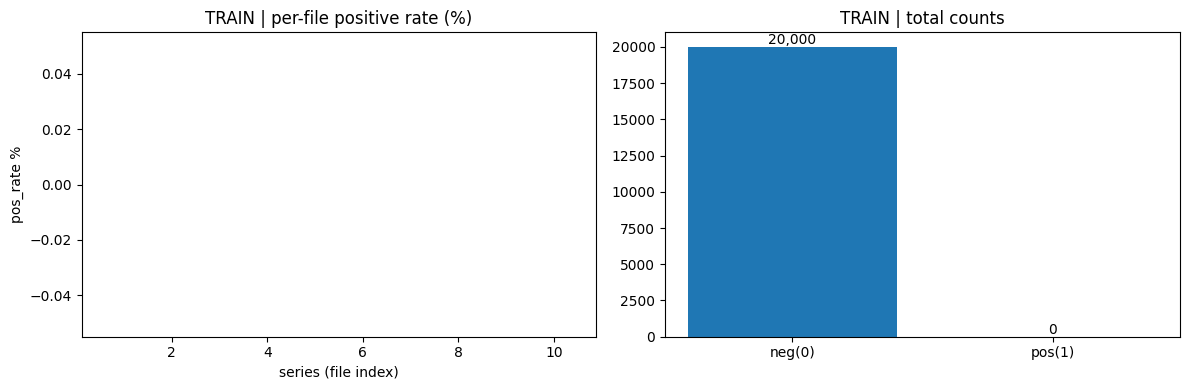

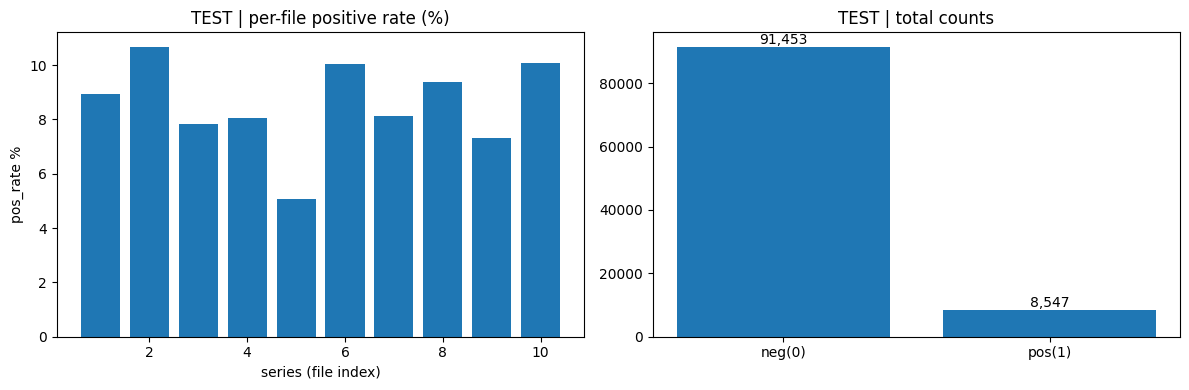

[TRAIN] overall positive rate: 0.0000%
  -> Highly imbalanced (positives < 1.0% of total).
  Files with <10 positives: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[TEST] overall positive rate: 8.5470%
  Files with >10 positives: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
# ==== EDA: Class-balance (Labels) for train/test ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose which lists to use (engineered or raw)
_train = train_fe if 'train_fe' in globals() else train_files
_test  = test_fe  if 'test_fe'  in globals() else test_files

def _summarize_split(dfs, split_name="train"):
    rows = []
    for i, df in enumerate(dfs, start=1):
        if "Labels" not in df.columns:
            rows.append({"series": i, "n": len(df), "pos(1)": np.nan, "neg(0)": np.nan,
                         "pos_rate%": np.nan})
            continue
        y = df["Labels"].to_numpy().astype(int).ravel()
        n  = len(y)
        p  = int((y == 1).sum())
        n0 = n - p
        pos_rate = 100.0 * p / n if n > 0 else np.nan
        rows.append({"series": i, "n": n, "pos(1)": p, "neg(0)": n0, "pos_rate%": pos_rate})
    tab = pd.DataFrame(rows)

    # Totals
    if tab["pos(1)"].notna().all():
        tot_n = int(tab["n"].sum())
        tot_p = int(tab["pos(1)"].sum())
        tot_n0 = tot_n - tot_p
        tot_rate = 100.0 * tot_p / tot_n if tot_n > 0 else np.nan
        print(f"\n[{split_name.upper()}] totals: N={tot_n:,} | pos(1)={tot_p:,} | neg(0)={tot_n0:,} | pos_rate={tot_rate:.3f}%")
    else:
        print(f"\n[{split_name.upper()}] Some files missing 'Labels' column; table shows NaN.")

    return tab

train_tab = _summarize_split(_train, "train")
test_tab  = _summarize_split(_test,  "test")

print("\n[TRAIN] per-file class balance:")
display(train_tab)

print("\n[TEST] per-file class balance:")
display(test_tab)

# --- Quick visuals ---
def _bar_plot(tab, title):
    if tab["pos(1)"].isna().any():
        return
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    # per file positive rate
    ax[0].bar(tab["series"], tab["pos_rate%"])
    ax[0].set_title(f"{title} | per-file positive rate (%)")
    ax[0].set_xlabel("series (file index)")
    ax[0].set_ylabel("pos_rate %")
    # global counts
    pos = int(tab["pos(1)"].sum())
    neg = int(tab["neg(0)"].sum())
    ax[1].bar(["neg(0)", "pos(1)"], [neg, pos])
    ax[1].set_title(f"{title} | total counts")
    for i, v in enumerate([neg, pos]):
        ax[1].text(i, v, f"{v:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

_bar_plot(train_tab, "TRAIN")
_bar_plot(test_tab,  "TEST")

# --- Quick flags for imbalance ---
def _imbalance_flag(tab, name, threshold_pos_rate=1.0):
    if tab["pos(1)"].isna().any():
        print(f"[{name}] Skipped imbalance check (missing Labels).")
        return
    tot_n = int(tab["n"].sum())
    tot_p = int(tab["pos(1)"].sum())
    rate = 100.0 * tot_p / tot_n if tot_n > 0 else np.nan
    print(f"[{name}] overall positive rate: {rate:.4f}%")
    if rate < threshold_pos_rate:
        print(f"  -> Highly imbalanced (positives < {threshold_pos_rate}% of total).")
    # per-file anomaly counts (useful since your test files have exactly 10 anomalies)
    low = tab.loc[tab["pos(1)"] < 10, "series"].tolist()
    high = tab.loc[tab["pos(1)"] > 10, "series"].tolist()
    if len(low):
        print(f"  Files with <10 positives: {low}")
    if len(high):
        print(f"  Files with >10 positives: {high}")

_imbalance_flag(train_tab, "TRAIN", threshold_pos_rate=1.0)
_imbalance_flag(test_tab,  "TEST",  threshold_pos_rate=1.0)


In [ ]:
# EDA | Cell 4: label distribution per file and overall
def label_distribution(dfs, split_name="train"):
    if "Labels" not in dfs[0].columns:
        print(f"[{split_name}] No 'Labels' column — skipping.")
        return
    per = []
    for i, df in enumerate(dfs, 1):
        c = Counter(df["Labels"].astype(int))
        per.append({"series": i, "neg": c.get(0,0), "pos": c.get(1,0), "pos_pct": 100.0*c.get(1,0)/len(df)})
    tab = pd.DataFrame(per).set_index("series")
    print(f"=== LABEL DISTRIBUTION ({split_name}) ===")
    display(tab)
    print("Overall pos pct:", 100.0 * sum(df["Labels"].sum() for df in dfs) / sum(len(df) for df in dfs), "%")
    print()

label_distribution(train_files, "train")
label_distribution(test_files,  "test")


=== LABEL DISTRIBUTION (train) ===


,neg,pos,pos_pct
series,,,
1,2000,0,0.0
2,2000,0,0.0
3,2000,0,0.0
4,2000,0,0.0
5,2000,0,0.0
6,2000,0,0.0
7,2000,0,0.0
8,2000,0,0.0
9,2000,0,0.0


Overall pos pct: 0.0 %

=== LABEL DISTRIBUTION (test) ===


,neg,pos,pos_pct
series,,,
1,9108,892,8.92
2,8933,1067,10.67
3,9216,784,7.84
4,9196,804,8.04
5,9492,508,5.08
6,8996,1004,10.04
7,9189,811,8.11
8,9064,936,9.36
9,9267,733,7.33


Overall pos pct: 8.547 %



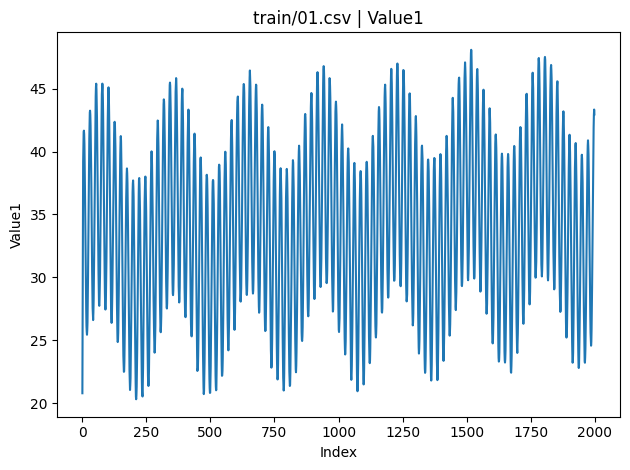

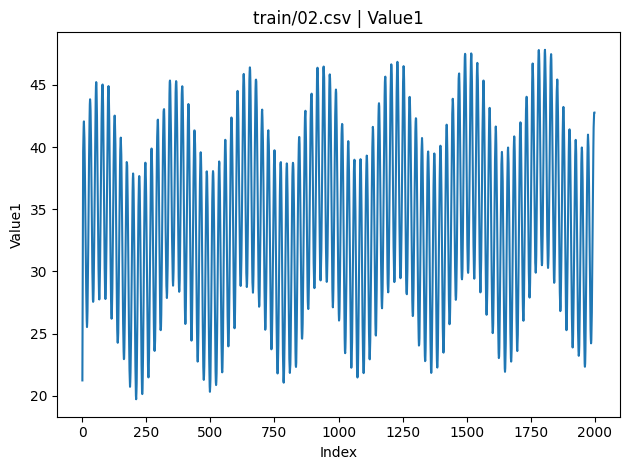

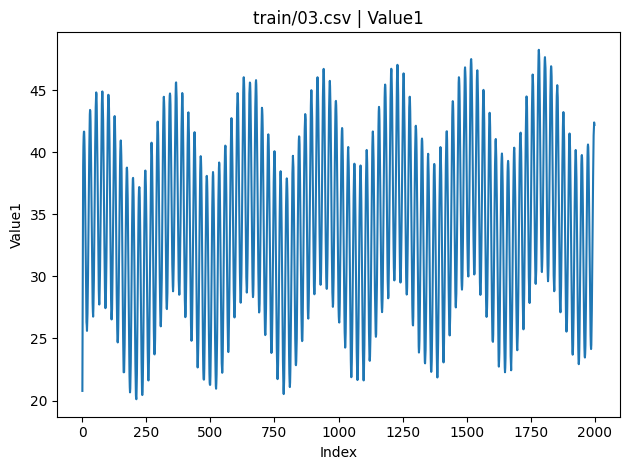

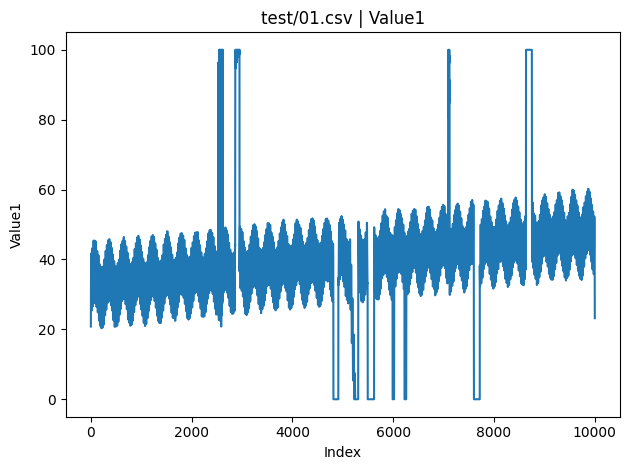

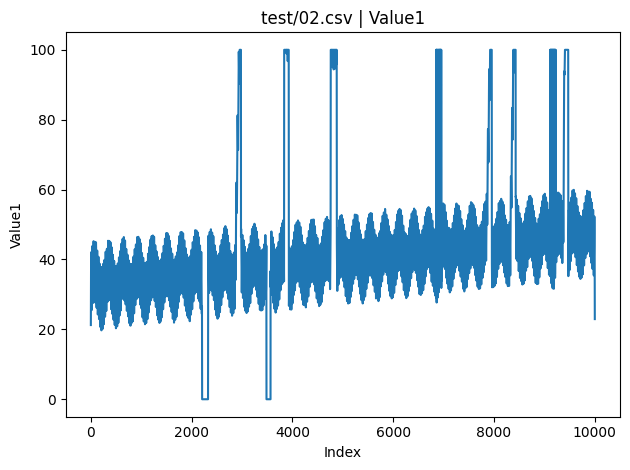

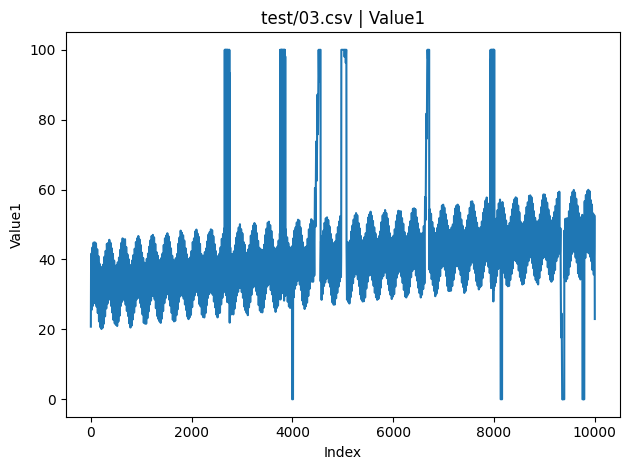

In [ ]:
# EDA | Cell 5: quick line plots
def quick_plot(dfs, split_name="train", value_col="Value1", k=3):
    n = min(k, len(dfs))
    for i in range(n):
        x = dfs[i][value_col].to_numpy(dtype=float)
        plt.figure()
        plt.plot(np.arange(len(x)), x)
        plt.title(f"{split_name}/{i+1:02d}.csv | {value_col}")
        plt.xlabel("Index")
        plt.ylabel(value_col)
        plt.tight_layout()

quick_plot(train_files, "train", "Value1", k=3)
quick_plot(test_files,  "test",  "Value1", k=3)


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

VALUE_COL = "Value1"
ROLL_WIN  = 401   # centered rolling median for de-trending

def detrend_resid(x, w=ROLL_WIN):
    s = pd.Series(x)
    med = s.rolling(w, center=True, min_periods=w//2).median()
    med = med.fillna(method="bfill").fillna(method="ffill")
    return (s - med).to_numpy()

def zscore(a, eps=1e-12):
    a = np.asarray(a, float)
    return (a - a.mean()) / max(a.std(ddof=0), eps)

def normality_tests_1d(x, sample_for_shapiro=5000, random_state=42):
    """x should be roughly iid residuals (detrended). Returns dict of test stats/p-values."""
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, float)
    # Shapiro (recommended n <= 5000)
    if len(x) > sample_for_shapiro:
        x_sh = rng.choice(x, size=sample_for_shapiro, replace=False)
    else:
        x_sh = x
    sh_stat, sh_p = stats.shapiro(x_sh)

    # D'Agostino's K^2
    dag_stat, dag_p = stats.normaltest(x, nan_policy="omit")

    # Anderson–Darling (gives critical values; no p-value)
    ad_res = stats.anderson(x, dist='norm')

    # Jarque–Bera (skewness/kurtosis based)
    jb_stat, jb_p = stats.jarque_bera(x)

    # Kolmogorov–Smirnov with estimated μ,σ (Lilliefors-style heuristic)
    # standardize and compare to N(0,1)
    x_std = zscore(x)
    ks_stat, ks_p = stats.kstest(x_std, 'norm')

    return {
        "shapiro_stat": float(sh_stat), "shapiro_p": float(sh_p),
        "dagostino_stat": float(dag_stat), "dagostino_p": float(dag_p),
        "anderson_stat": float(ad_res.statistic),
        "anderson_crit_vals": ad_res.critical_values.tolist(),
        "anderson_sig_lvls": ad_res.significance_level.tolist(),
        "jarque_bera_stat": float(jb_stat), "jarque_bera_p": float(jb_p),
        "ks_stat": float(ks_stat), "ks_p": float(ks_p),
    }

rows = []
for split_name, dfs in [("train", train_files), ("test", test_files)]:
    for i, df in enumerate(dfs, start=1):
        x = df[VALUE_COL].to_numpy(dtype=float)
        r = detrend_resid(x)
        r = r[np.isfinite(r)]
        out = normality_tests_1d(r)
        out.update({"split": split_name, "series": i, "n": int(len(r))})
        rows.append(out)

normality_summary = pd.DataFrame(rows).set_index(["split","series"])
display(normality_summary)


/tmp/ipython-input-1608691148.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  med = med.fillna(method="bfill").fillna(method="ffill")


shapiro_stat     shapiro_p  dagostino_stat    dagostino_p  \
split series                                                              
train 1           0.977195  2.467035e-17      324.828978   2.912619e-71   
      2           0.977105  2.265347e-17      325.931704   1.678146e-71   
      3           0.976434  1.208881e-17      348.941014   1.692083e-76   
      4           0.977567  3.518004e-17      316.389751   1.980790e-69   
      5           0.977702  4.008339e-17      314.652845   4.720661e-69   
      6           0.976290  1.057712e-17      362.419003   2.003150e-79   
      7           0.976924  1.910778e-17      326.257578   1.425828e-71   
      8           0.976679  1.518099e-17      342.419880   4.410296e-75   
      9           0.975560  5.436221e-18      367.028315   1.999006e-80   
      10          0.977446  3.134381e-17      325.247834   2.362274e-71   
test  1           0.837926  1.106358e-57     1862.595006   0.000000e+00   
      2           0.789014  1.328286e-62     3927.087590   0.000000e+00   
      3           0.789911  1.601408e-62     3767.950848   0.000000e+00   
      4           0.855599  1.357916e-55     1295.725621  4.332678e-282   
      5           0.765418  1.221964e-64     4799.400200   0.000000e+00   
      6           0.851290  4.023949e-56     1760.153257   0.000000e+00   
      7           0.805736  4.855374e-61     4026.849328   0.000000e+00   
      8           0.745633  3.229638e-66     5042.302280   0.000000e+00   
      9           0.841395  2.744318e-57     1594.780501   0.000000e+00   
      10          0.806453  5.697710e-61     2958.142696   0.000000e+00   

              anderson_stat                   anderson_crit_vals  \
split series                                                       
train 1            9.141441   [0.575, 0.655, 0.785, 0.916, 1.09]   
      2            9.119929   [0.575, 0.655, 0.785, 0.916, 1.09]   
      3            9.550489   [0.575, 0.655, 0.785, 0.916, 1.09]   
      4            8.968549   [0.575, 0.655, 0.785, 0.916, 1.09]   
      5            8.839116   [0.575, 0.655, 0.785, 0.916, 1.09]   
      6           10.003940   [0.575, 0.655, 0.785, 0.916, 1.09]   
      7            9.067228   [0.575, 0.655, 0.785, 0.916, 1.09]   
      8            9.420946   [0.575, 0.655, 0.785, 0.916, 1.09]   
      9            9.999081   [0.575, 0.655, 0.785, 0.916, 1.09]   
      10           9.142225   [0.575, 0.655, 0.785, 0.916, 1.09]   
test  1          381.882190  [0.576, 0.656, 0.787, 0.918, 1.092]   
      2          549.969149  [0.576, 0.656, 0.787, 0.918, 1.092]   
      3          405.142692  [0.576, 0.656, 0.787, 0.918, 1.092]   
      4          289.493857  [0.576, 0.656, 0.787, 0.918, 1.092]   
      5          447.962064  [0.576, 0.656, 0.787, 0.918, 1.092]   
      6          342.190285  [0.576, 0.656, 0.787, 0.918, 1.092]   
      7          469.461999  [0.576, 0.656, 0.787, 0.918, 1.092]   
      8          599.153487  [0.576, 0.656, 0.787, 0.918, 1.092]   
      9          234.365114  [0.576, 0.656, 0.787, 0.918, 1.092]   
      10         550.822364  [0.576, 0.656, 0.787, 0.918, 1.092]   

                        anderson_sig_lvls  jarque_bera_stat  jarque_bera_p  \
split series                                                                 
train 1       [15.0, 10.0, 5.0, 2.5, 1.0]         73.556608   1.065088e-16   
      2       [15.0, 10.0, 5.0, 2.5, 1.0]         73.683968   9.993776e-17   
      3       [15.0, 10.0, 5.0, 2.5, 1.0]         75.819232   3.436077e-17   
      4       [15.0, 10.0, 5.0, 2.5, 1.0]         72.728991   1.611018e-16   
      5       [15.0, 10.0, 5.0, 2.5, 1.0]         72.570399   1.743966e-16   
      6       [15.0, 10.0, 5.0, 2.5, 1.0]         77.020685   1.884390e-17   
      7       [15.0, 10.0, 5.0, 2.5, 1.0]         73.695415   9.936741e-17   
      8       [15.0, 10.0, 5.0, 2.5, 1.0]         75.219289   4.638088e-17   
      9       [15.0, 10.0, 5.0, 2.5, 1.0]         77.406907   1.553473e-17   
      10

train/01 | n=2000
  Shapiro_p: 2.467e-17
  DAgostino_p: 2.913e-71
  JarqueBera_p: 1.065e-16
  KS_p: 0.001855
  Anderson_stat: 9.141
  Anderson_crit@15%: 0.575
  Anderson_crit@5%: 0.785
  Anderson_crit@1%: 1.09
  Rule of thumb: p < 0.05 => reject normality; for Anderson, stat > critical => reject.



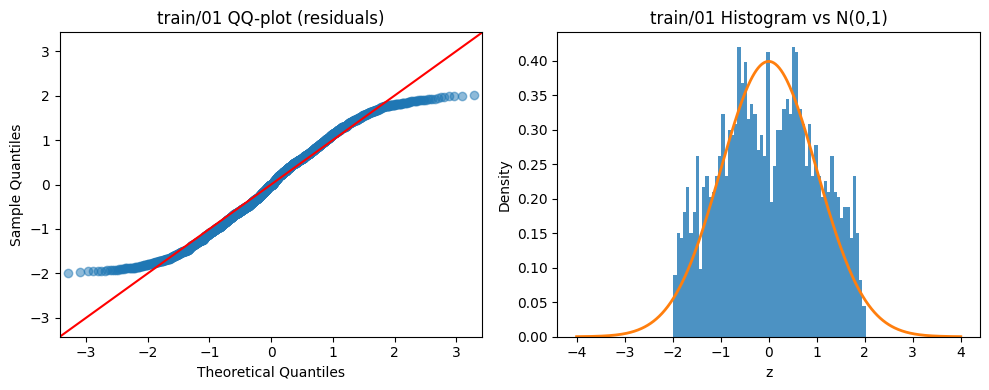

test/01 | n=10000
  Shapiro_p: 1.106e-57
  DAgostino_p: 0
  JarqueBera_p: 0
  KS_p: 1.91e-124
  Anderson_stat: 381.9
  Anderson_crit@15%: 0.576
  Anderson_crit@5%: 0.787
  Anderson_crit@1%: 1.092
  Rule of thumb: p < 0.05 => reject normality; for Anderson, stat > critical => reject.



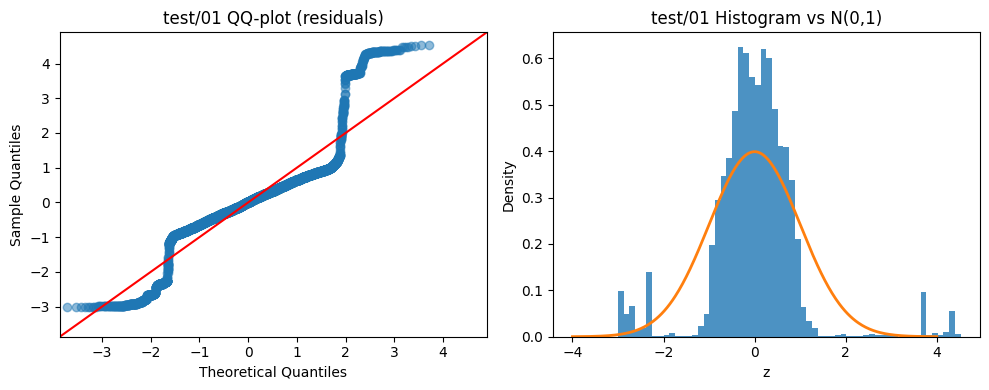

In [ ]:
# === Gaussianity check (run BEFORE feature engineering) ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm  # ensure installed

VALUE_COL = "Value1"
ROLL_WIN  = 401        # centered rolling median window for detrending
SHAPIRO_MAX = 5000     # Shapiro is reliable up to ~5000 samples

def detrend_residuals(x: np.ndarray, w: int = ROLL_WIN) -> np.ndarray:
    """Robust detrending via centered rolling median; returns residuals."""
    s = pd.Series(x, dtype=float)
    med = s.rolling(w, center=True, min_periods=w//2).median()
    # No deprecated 'method' kw; use ffill/bfill
    med = med.bfill().ffill()
    r = (s - med).to_numpy()
    return r[np.isfinite(r)]

def zscore(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, float)
    return (a - a.mean()) / max(a.std(ddof=0), eps)

def normality_tests_1d(x: np.ndarray, seed: int = 42):
    rng = np.random.default_rng(seed)
    # Shapiro (subsample if very long)
    xs = x if len(x) <= SHAPIRO_MAX else rng.choice(x, size=SHAPIRO_MAX, replace=False)
    sh_stat, sh_p = stats.shapiro(xs)
    # D’Agostino K^2
    dag_stat, dag_p = stats.normaltest(x, nan_policy="omit")
    # Jarque–Bera
    jb_stat, jb_p = stats.jarque_bera(x)
    # Kolmogorov–Smirnov against N(0,1) after standardizing
    x_std = zscore(x)
    ks_stat, ks_p = stats.kstest(x_std, 'norm')
    # Anderson–Darling gives critical values (no p); keep for reference
    ad = stats.anderson(x, dist='norm')
    return {
        "Shapiro_p": float(sh_p),
        "DAgostino_p": float(dag_p),
        "JarqueBera_p": float(jb_p),
        "KS_p": float(ks_p),
        "Anderson_stat": float(ad.statistic),
        "Anderson_crit@15%": float(ad.critical_values[0]),
        "Anderson_crit@5%":  float(ad.critical_values[2]),
        "Anderson_crit@1%":  float(ad.critical_values[4]),
    }

def gaussianity_panel(df: pd.DataFrame, title: str):
    x = df[VALUE_COL].to_numpy(dtype=float)
    r = detrend_residuals(x, w=ROLL_WIN)
    r_std = zscore(r)

    # Print precise test values
    tests = normality_tests_1d(r)
    print(f"{title} | n={len(r)}")
    for k, v in tests.items():
        print(f"  {k}: {v:.4g}")
    print("  Rule of thumb: p < 0.05 => reject normality; for Anderson, stat > critical => reject.\n")

    # Plots: single figure, two subplots (no blank axes)
    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(1, 2, 1)
    sm.ProbPlot(r_std).qqplot(line='45', alpha=0.5, lw=1, ax=ax1)
    ax1.set_title(f"{title} QQ-plot (residuals)")
    ax1.set_xlabel("Theoretical Quantiles"); ax1.set_ylabel("Sample Quantiles")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.hist(r_std, bins=60, density=True, alpha=0.8)
    xx = np.linspace(-4, 4, 401)
    ax2.plot(xx, stats.norm.pdf(xx), lw=2)
    ax2.set_title(f"{title} Histogram vs N(0,1)")
    ax2.set_xlabel("z"); ax2.set_ylabel("Density")
    fig.tight_layout()
    plt.show()

# === Run on a couple of series (adjust indices as you like) ===================
gaussianity_panel(train_files[0], "train/01")
gaussianity_panel(test_files[0],  "test/01")


Not Gaussian

# **The Model**

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

warnings.filterwarnings(
    "ignore",
    message="Determinant has increased; this should not happen"
)

@njit
def create_windows_numba(series, window_size):
    n_windows = len(series) - window_size + 1
    windows = np.empty((n_windows, window_size), dtype=np.float32)
    for i in range(n_windows):
        windows[i, :] = series[i : i + window_size]
    return windows

@njit
def normalize_scores(scores):
    mn = np.min(scores)
    mx = np.max(scores)
    return (scores - mn) / (mx - mn + 1e-8)


class AnomalyDetectionModel:
    def __init__(self, window_size=30, contamination=0.01):
        self.window_size = window_size
        self.offset = window_size // 2
        self.contamination = contamination

        self.scaler = StandardScaler()
        self.models = {
            'IsolationForest': IsolationForest(contamination=contamination, random_state=42),
            'OneClassSVM': OneClassSVM(kernel='rbf', gamma='scale', nu=contamination),
            'EllipticEnvelope': EllipticEnvelope(contamination=contamination,
                                                 support_fraction=0.75,
                                                 random_state=42),
        }

        self.use_lof = True
        self.lof_model = LocalOutlierFactor(n_neighbors=20,
                                            contamination=contamination,
                                            novelty=True)
        self.full_anomaly_mask = None

    def fit(self, X: np.ndarray, y: np.ndarray = None):
        self.train_windows = self._create_windows(X)
        self.scaled_train_windows = self.scaler.fit_transform(self.train_windows)
        for model in self.models.values():
            model.fit(self.scaled_train_windows)
        if self.use_lof:
            self.lof_model.fit(self.scaled_train_windows)

    def predict(self, X: np.ndarray):

        test_windows = self._create_windows(X)
        scaled = self.scaler.transform(test_windows)


        all_scores = []
        for model in self.models.values():
            if hasattr(model, "decision_function"):
                s = model.decision_function(scaled)
                all_scores.append(normalize_scores(s))
            else:
                preds = model.predict(scaled)
                all_scores.append(np.where(preds == -1, 0.0, 1.0))

        if self.use_lof:
            lof_s = self.lof_model.decision_function(scaled)
            all_scores.append(normalize_scores(lof_s))

        avg_scores = np.mean(np.stack(all_scores, axis=0), axis=0)
        thresh = np.percentile(avg_scores, self.contamination * 100)
        mask = np.zeros(len(X), dtype=int)
        mask[self.offset : self.offset + len(avg_scores)] = (avg_scores <= thresh).astype(int)
        self.full_anomaly_mask = mask
        idx = np.argmin(avg_scores)
        return idx + self.offset
    def _create_windows(self, series: np.ndarray):
        return create_windows_numba(series, self.window_size)

## Explanation

This pipeline works on the idea that:

        1) it builds upon sliding windows
        2) gathers normalised anomaly scores from each sub-model and uses them
        3) averages the anomaly scores
        4) computes a binary mask by thresholding at the 1st percentile so that it can compare outputs
        5) stores self.full_anomaly_mask (same length as the placeholder value)
        6) returns the single index of the lowest‐score window center which closes the loop on the sliding window idea


## **STUDENT TODO — Implement your anomaly detector**
Implement Machine Learning/ Statistical models or both. Use the test_files (test series) to train your models and list of anomaly index range for example Anomaly 1:   2001-2005
Anomaly 2:   2010-2012


**Constraints**

- Keep it efficient; we will run this over 10 datasets and additional novel datasets in class.



In [ ]:
# === Student do: CONFIG + UTILS (shared) ===
import numpy as np
import pandas as pd
import warnings
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# ---- Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Precision-oriented postprocessing knobs (edit here)
K_PER_FILE    = 10     # we must output 10 anomalies per file
SPAN          = 4      # each anomaly covers 4 indices (end-exclusive)
SMOOTH_WIN    = 21     # moving-average smoothing (odd)
NMS_SUPPRESS  = 60     # non-max suppression half-width
TARGET_RATE   = None   # if None, derive from K_PER_FILE*SPAN/N; else e.g. 0.004

# ---- Small utilities
def minmax01(a):
    a = np.asarray(a, float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    return np.zeros_like(a, dtype=np.float32) if hi-lo < 1e-12 else ((a-lo)/(hi-lo)).astype(np.float32)

def robust_fit(X):
    med = np.median(X, axis=0)
    iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
    scale = np.maximum(iqr / 1.349, 1e-9)
    return med.astype(np.float32), scale.astype(np.float32)

def robust_transform(X, med, scale):
    return ((X - med) / scale).astype(np.float32)

def smooth_scores(s, win=21):
    win = int(win)
    if win <= 1 or win % 2 == 0: win = max(1, win | 1)
    if win == 1: return s.astype(np.float32)
    k = np.ones(win, np.float32)/win
    return np.convolve(s.astype(np.float32), k, mode="same").astype(np.float32)

def nms_topk(s, k, suppress):
    order = np.argsort(-s)
    chosen, blocked = [], np.zeros(len(s), dtype=bool)
    for idx in order:
        if blocked[idx]: continue
        chosen.append(idx)
        lo = max(0, idx - suppress)
        hi = min(len(s), idx + suppress + 1)
        blocked[lo:hi] = True
        if len(chosen) >= k: break
    return sorted(chosen)

def snap_to_local_peak(s, centers, window=25):
    snapped = []
    N = len(s)
    for c in centers:
        lo = max(0, c-window); hi = min(N, c+window+1)
        loc = lo + int(np.argmax(s[lo:hi])) if hi>lo else c
        snapped.append(loc)
    # unique & sorted (avoid tiny duplicates)
    return sorted(set(snapped))

def fixed_ranges_from_centers(centers, N, span=4):
    return [(int(c), min(N, int(c)+span)) for c in centers]

def ranges_to_mask(ranges, N):
    m = np.zeros(N, dtype=int)
    for s,e in ranges:
        if s<e: m[s:e]=1
    return m

def labels_with_tolerance(y, tol=2):
    y = np.asarray(y, int).ravel()
    N = len(y); out = np.zeros_like(y)
    pos = np.where(y==1)[0]
    for p in pos:
        lo=max(0,p-tol); hi=min(N,p+tol+1); out[lo:hi]=1
    return out

def confusion_from_masks(pred_mask, y_mask):
    tp = int(((pred_mask==1)&(y_mask==1)).sum())
    fp = int(((pred_mask==1)&(y_mask==0)).sum())
    fn = int(((pred_mask==0)&(y_mask==1)).sum())
    tn = int(((pred_mask==0)&(y_mask==0)).sum())
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":prec,"recall":rec,"f1":f1}


In [ ]:
#Feature engineering
# ---- knobs (tweak as needed) ----
FE_VALUE_COL = "Value1"
FE_LABEL_COL = "Labels"

# Context choices
FE_LAGS    = (1, 2, 3, 5, 10)         # previous steps to include as features
FE_WINS    = (11, 51, 101)            # rolling/robust windows
FE_EMA     = (5, 20)                  # EMA spans
FE_DIFFS   = (1,)                     # differences x[t]-x[t-k]
FE_PCT     = True                     # 1-step percent change

# Missing handling
FE_DROP_NA = True                     # drop first rows invalidated by lags/rolls
FE_FILL    = False                    # alternative: forward/back fill if preferred

# Robust z clipping (keeps models stable)
FE_CLIP_Z  = 10.0                     # None to disable


# ---------- helpers ----------
def _rolling_iqr(s: pd.Series, w: int) -> pd.Series:
    q75 = s.rolling(w, center=False, min_periods=w//2).quantile(0.75)
    q25 = s.rolling(w, center=False, min_periods=w//2).quantile(0.25)
    return q75 - q25

def _rolling_median(s: pd.Series, w: int) -> pd.Series:
    return s.rolling(w, center=False, min_periods=w//2).median()

def _rolling_mad(s: pd.Series, w: int) -> pd.Series:
    med = _rolling_median(s, w)
    return (s.sub(med).abs()).rolling(w, center=False, min_periods=w//2).median()

def _safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    return a / b.replace(0, np.nan)

def _mk_meta(name: str, desc: str, kind: str, params: dict) -> dict:
    return {"feature": name, "description": desc, "kind": kind, "params": params}


def feature_engineer_df(
    df: pd.DataFrame,
    value_col: str = FE_VALUE_COL,
    label_col: str = FE_LABEL_COL,
    lags=FE_LAGS,
    wins=FE_WINS,
    ema_spans=FE_EMA,
    diffs=FE_DIFFS,
    add_pct: bool = FE_PCT,
    drop_na: bool = FE_DROP_NA,
    fill_missing: bool = FE_FILL,
    clip_z: float | None = FE_CLIP_Z,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      - df_fe: COPY of df with new columns (Index, GlobalMean, RollMean_*, feat_*)
      - meta : DataFrame of feature metadata (feature, description, kind, params)
    """
    d = df.copy(deep=True)
    x = d[value_col].astype(float)
    n = len(d)

    meta_rows = []

    # --- Index feature (position in series) ---
    d["Index"] = d.index.to_numpy()
    meta_rows.append(_mk_meta("Index", "Row index position (0..N-1).", "index", {}))

    # --- Global mean (constant per file) ---
    gm = float(x.mean())
    d["GlobalMean"] = gm
    meta_rows.append(_mk_meta("GlobalMean", "Global mean of Value1 for this file (constant).", "global", {}))

    # --- Rolling mean (simple local trend; requested) ---
    for w in wins:
        col = f"RollMean_{w}"
        d[col] = x.rolling(w, min_periods=w//2).mean()
        meta_rows.append(_mk_meta(col, f"Rolling mean over window {w}. Captures local trend.", "rolling", {"window": w}))

    # --- Lags (short-term memory) ---
    for k in lags:
        col = f"feat_lag_{k}"
        d[col] = x.shift(k)
        meta_rows.append(_mk_meta(col, f"Lagged value x[t-{k}] (previous step).", "lag", {"lag": k}))

    # --- Differences (jumps/slopes) ---
    for k in diffs:
        col = f"feat_diff_{k}"
        d[col] = x.diff(k)
        meta_rows.append(_mk_meta(col, f"Difference x[t]-x[t-{k}] (change over {k}).", "diff", {"lag": k}))

    # --- Percent change (scale-invariant change) ---
    if add_pct:
        col = "feat_pct_change_1"
        d[col] = x.pct_change().replace([np.inf, -np.inf], np.nan)
        meta_rows.append(_mk_meta(col, "Percent change from previous step.", "pct_change", {"lag": 1}))

    # --- Rolling/robust stats + robust z-like scores ---
    for w in wins:
        # classic stats
        d[f"feat_roll_mean_{w}"] = x.rolling(w, min_periods=w//2).mean()
        d[f"feat_roll_std_{w}"]  = x.rolling(w, min_periods=w//2).std(ddof=0)
        d[f"feat_roll_min_{w}"]  = x.rolling(w, min_periods=w//2).min()
        d[f"feat_roll_max_{w}"]  = x.rolling(w, min_periods=w//2).max()
        meta_rows += [
            _mk_meta(f"feat_roll_mean_{w}", f"Rolling mean (w={w}).", "rolling", {"window": w}),
            _mk_meta(f"feat_roll_std_{w}",  f"Rolling std (w={w}) — local volatility.", "rolling", {"window": w}),
            _mk_meta(f"feat_roll_min_{w}",  f"Rolling min (w={w}).", "rolling", {"window": w}),
            _mk_meta(f"feat_roll_max_{w}",  f"Rolling max (w={w}).", "rolling", {"window": w}),
        ]

        # robust stats
        med = _rolling_median(x, w)
        mad = _rolling_mad(x, w)
        iqr = _rolling_iqr(x, w)
        d[f"feat_roll_med_{w}"] = med
        d[f"feat_roll_mad_{w}"] = mad
        d[f"feat_roll_iqr_{w}"] = iqr
        meta_rows += [
            _mk_meta(f"feat_roll_med_{w}", f"Rolling median (w={w}) — robust trend.", "robust", {"window": w}),
            _mk_meta(f"feat_roll_mad_{w}", f"Rolling MAD (w={w}) — robust spread.", "robust", {"window": w}),
            _mk_meta(f"feat_roll_iqr_{w}", f"Rolling IQR (w={w}) — robust spread.", "robust", {"window": w}),
        ]

        # deviation from robust center
        dev = x - med
        d[f"feat_dev_med_{w}"] = dev
        meta_rows.append(_mk_meta(f"feat_dev_med_{w}", f"Deviation from rolling median (w={w}).", "robust_dev", {"window": w}))

        # robust z-like: MAD-z
        mad_scale = (1.4826 * mad).replace(0, np.nan)
        rz = _safe_div(dev.abs(), mad_scale)
        if clip_z is not None:
            rz = rz.clip(upper=clip_z)
        d[f"feat_rz_{w}"] = rz
        meta_rows.append(_mk_meta(f"feat_rz_{w}",
                                  f"Robust z-like: |x - median| / (1.4826*MAD), w={w}. High => outlier.",
                                  "robust_z_mad", {"window": w, "scale": "MAD"}))

        # robust z-like: IQR-z
        iqr_scale = (iqr / 1.349).replace(0, np.nan)  # σ ≈ IQR/1.349 for normal
        zi = _safe_div(dev.abs(), iqr_scale)
        if clip_z is not None:
            zi = zi.clip(upper=clip_z)
        d[f"feat_zi_{w}"] = zi
        meta_rows.append(_mk_meta(f"feat_zi_{w}",
                                  f"Robust z-like: |x - median| / (IQR/1.349), w={w}.",
                                  "robust_z_iqr", {"window": w, "scale": "IQR"}))

    # --- EMAs and deviations (faster trend) ---
    for span in ema_spans:
        ema_col = f"feat_ema_{span}"
        dev_col = f"feat_dev_ema_{span}"
        d[ema_col] = x.ewm(span=span, adjust=False, min_periods=span//2).mean()
        d[dev_col] = x - d[ema_col]
        meta_rows += [
            _mk_meta(ema_col, f"Exponential moving average (span={span}).", "ema", {"span": span}),
            _mk_meta(dev_col, f"Deviation from EMA (span={span}).", "ema_dev", {"span": span}),
        ]

    # --- Missing handling / trimming ---
    if fill_missing:
        d = d.fillna(method="ffill").fillna(method="bfill")

    if drop_na:
        max_lag = max(lags) if lags else 0
        max_win = max(wins) if wins else 1
        drop_head = max(max_lag, max_win)
        d = d.iloc[drop_head:].copy()

    # Hygiene
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    if not fill_missing and drop_na:
        d.dropna(inplace=True)

    # Build metadata DataFrame
    meta = pd.DataFrame(meta_rows, columns=["feature","description","kind","params"])

    return d, meta


def feature_engineer_lists(train_list: list[pd.DataFrame],
                           test_list:  list[pd.DataFrame],
                           **kwargs) -> tuple[list[pd.DataFrame], list[pd.DataFrame], pd.DataFrame]:
    train_fe, test_fe = [], []
    meta_all = []

    for split_name, src_list, dst_list in (("train", train_list, train_fe), ("test", test_list, test_fe)):
        for i, df in enumerate(src_list, 1):
            fe_df, meta = feature_engineer_df(df, **kwargs)
            fe_df["__series_id__"] = i           # optional: for tracking
            fe_df["__split__"]     = split_name   # optional: split tag
            dst_list.append(fe_df)
            # tag metadata with split/series (for auditing)
            meta = meta.copy()
            meta["split"] = split_name
            meta["series"] = i
            meta_all.append(meta)

    meta_table = pd.concat(meta_all, ignore_index=True)
    return train_fe, test_fe, meta_table

# === Student do: FE POLISH + LIGHT PRUNING ===
# Call feature_engineer_lists to create train_fe and test_fe
train_fe, test_fe, fe_meta = feature_engineer_lists(
    train_files, test_files,
    value_col=FE_VALUE_COL,
    label_col=FE_LABEL_COL,
    lags=FE_LAGS,
    wins=FE_WINS,
    ema_spans=FE_EMA,
    diffs=FE_DIFFS,
    add_pct=FE_PCT,
    drop_na=FE_DROP_NA,
    fill_missing=FE_FILL,
    clip_z=FE_CLIP_Z,
)

# 2.1 ensure 'Index' exists in copies (do not mutate originals)
def with_index_col(df):
    out = df.copy()
    if "Index" not in out.columns:
        out["Index"] = np.arange(len(out), dtype=np.int32)
    return out

train_fe = [with_index_col(d) for d in train_fe]
test_fe  = [with_index_col(d) for d in test_fe]

# 2.2 feature list (exclude target/label)
BLOCKLIST = {"Value1","Labels","GlobalMean"}
def _is_feat(c: str) -> bool:
    return (
        c.startswith(("feat_","Roll","EMA","RZ_","IQR_","pct_","lag_","diff_"))
        or c.endswith(("_ema","_mad","_iqr","_std","_mean","_min","_max","_med"))
        or c in {"Index"}   # keep Index explicitly
    ) and (c not in BLOCKLIST)

feat_all = [c for c in train_fe[0].columns if _is_feat(c)]
feat_all = [c for c in feat_all if all(c in df.columns for df in train_fe+test_fe)]

# 2.3 variance ~0 filter + correlation pruning (keeps one per highly correlated group)
def variance_mask(X, thr=1e-12):
    v = np.var(X, axis=0)
    return v > thr

def corr_prune(X, names, thr=0.95):
    if X.shape[1] <= 1: return np.ones(X.shape[1], dtype=bool)
    samp = X if len(X) <= 20000 else X[np.random.default_rng(RANDOM_STATE).choice(len(X), 20000, replace=False)]
    C = np.corrcoef(samp, rowvar=False)
    C = np.nan_to_num(C, nan=0.0)
    keep = np.ones(C.shape[0], dtype=bool)
    for i in range(C.shape[0]):
        if not keep[i]: continue
        too = np.where(np.abs(C[i]) >= thr)[0]
        for j in too:
            if j > i: keep[j] = False
    return keep

# Build a stacked matrix for pruning decisions (train only)
X_stack = np.concatenate([d[feat_all].to_numpy(np.float32) for d in train_fe], axis=0)
mask_var = variance_mask(X_stack)
feat_vt  = [f for f,m in zip(feat_all, mask_var) if m]
X_vt     = X_stack[:, mask_var]
mask_corr = corr_prune(X_vt, feat_vt, thr=0.95)
feat_sel = [f for f,m in zip(feat_vt, mask_corr) if m]

print(f"[FE] kept {len(feat_sel)}/{len(feat_all)} features after var/corr pruning")

[FE] kept 28/45 features after var/corr pruning


In [ ]:
# === Student do: strip Labels from feature-engineered frames (keep y separately) ===
from copy import deepcopy
import numpy as np

LABEL_COL = FE_LABEL_COL  # "Labels" from your knobs

# Deep-copy to be extra safe (avoids mutating train_fe/test_fe you may reuse elsewhere)
train_fe_X = [df.drop(columns=[LABEL_COL], errors="ignore").copy(deep=True) for df in train_fe]
test_fe_X  = [df.drop(columns=[LABEL_COL], errors="ignore").copy(deep=True) for df in test_fe]

# Keep aligned label vectors for evaluation (if present)
y_train_fe = [df[LABEL_COL].to_numpy(dtype=int) if LABEL_COL in df.columns else None for df in train_fe]
y_test_fe  = [df[LABEL_COL].to_numpy(dtype=int) if LABEL_COL in df.columns else None for df in test_fe]

# (Optional) sanity prints
print(f"train_fe_X: {len(train_fe_X)} frames | test_fe_X: {len(test_fe_X)} frames")
print("Example shapes (first series):")
if len(train_fe_X):
    print("  X_train_fe[0]:", train_fe_X[0].shape, "| y_train_fe[0]:", None if y_train_fe[0] is None else y_train_fe[0].shape)
if len(test_fe_X):
    print("  X_test_fe[0]: ", test_fe_X[0].shape,  "| y_test_fe[0]: ", None if y_test_fe[0] is None else y_test_fe[0].shape)

# If you also maintain a feature list, ensure 'Labels' isn't in it:
if 'feat_all' in globals():
    feat_all = [c for c in feat_all if c != LABEL_COL]
if 'feat_sel' in globals():
    feat_sel = [c for c in feat_sel if c != LABEL_COL]

# Tip: downstream, use `train_fe_X` / `test_fe_X` for modeling (unsupervised),
# and `y_train_fe` / `y_test_fe` only for evaluation/metrics.


train_fe_X: 10 frames | test_fe_X: 10 frames
Example shapes (first series):
  X_train_fe[0]: (1899, 49) | y_train_fe[0]: (1899,)
  X_test_fe[0]:  (9034, 49) | y_test_fe[0]:  (9034,)


In [ ]:
# === Student do: MATRIX BUILD (selected features) ===
def to_matrix_on_cols(dfs, cols):
    return [df[cols].to_numpy(np.float32) for df in dfs]

X_train_list_sel = to_matrix_on_cols(train_fe, feat_sel)
X_test_list_sel  = to_matrix_on_cols(test_fe,  feat_sel)

print("Example shapes:", X_train_list_sel[0].shape, X_test_list_sel[0].shape)


Example shapes: (1899, 28) (9034, 28)


In [ ]:
from typing import List, Optional, Tuple
import numpy as np
import pandas as pd

def to_matrix_from_engineered(dfs: List[pd.DataFrame],
                              include_cols: Optional[List[str]] = None) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """
    Returns X_list, y_list aligned with input DFS.
    By default: all columns starting with 'feat_' or 'RollMean_', plus 'Index', 'GlobalMean'.
    """
    X_list, y_list = [], []
    for d in dfs:
        if include_cols is None:
            feat_cols = [c for c in d.columns if c.startswith("feat_") or c.startswith("RollMean_")]
            for extra in ("Index", "GlobalMean"):
                if extra in d.columns:
                    feat_cols.append(extra)
        else:
            feat_cols = include_cols

        X = d[feat_cols].to_numpy(dtype=np.float32)
        y = d["Labels"].to_numpy(dtype=int) if "Labels" in d.columns else np.zeros(len(d), dtype=int)
        X_list.append(X); y_list.append(y)
    return X_list, y_list

In [ ]:
def to_matrix_from_engineered(dfs: List[pd.DataFrame],
                              include_cols: Optional[List[str]] = None) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """
    Returns X_list, y_list aligned with input DFS.
    By default: all columns starting with 'feat_' or 'RollMean_', plus 'Index', 'GlobalMean'.
    """
    X_list, y_list = [], []
    for d in dfs:
        if include_cols is None:
            feat_cols = [c for c in d.columns if c.startswith("feat_") or c.startswith("RollMean_")]
            for extra in ("Index", "GlobalMean"):
                if extra in d.columns:
                    feat_cols.append(extra)
        else:
            feat_cols = include_cols

        X = d[feat_cols].to_numpy(dtype=np.float32)
        y = d["Labels"].to_numpy(dtype=int) if "Labels" in d.columns else np.zeros(len(d), dtype=int)
        X_list.append(X); y_list.append(y)
    return X_list, y_list



In [ ]:
# Create feature matrices from the engineered dataframes
X_train_list, y_train_list = to_matrix_from_engineered(train_fe)
X_test_list, _ = to_matrix_from_engineered(test_fe) # We don't need the labels for the test set here

MV

In [ ]:
import numpy as np
from typing import List, Tuple, Optional

def _contiguous_ranges_from_mask(mask: np.ndarray) -> List[Tuple[int,int]]:
    """Group consecutive 1's into (start, end_exclusive) ranges."""
    m = mask.astype(bool)
    if m.size == 0:
        return []
    diff = np.diff(m.astype(np.int32))
    starts = np.where(diff == 1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if m[0]:  starts = np.r_[0, starts]
    if m[-1]: ends   = np.r_[ends, len(m)]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _merge_close_ranges(ranges: List[Tuple[int,int]], gap: int = 0) -> List[Tuple[int,int]]:
    """Merge ranges separated by <= gap."""
    if not ranges:
        return []
    merged = [list(ranges[0])]
    for s, e in ranges[1:]:
        ps, pe = merged[-1]
        if s - pe <= gap:
            merged[-1][1] = max(pe, e)   # merge
        else:
            merged.append([s, e])
    return [(int(s), int(e)) for s, e in merged]

def _pad_and_filter_ranges(ranges: List[Tuple[int,int]], N: int, pad: int = 0, min_len: int = 1) -> List[Tuple[int,int]]:
    """Pad each range by ±pad, clip to [0,N], and drop short ranges."""
    out = []
    for s, e in ranges:
        s2 = max(0, s - pad)
        e2 = min(N, e + pad)
        if e2 - s2 >= min_len:
            out.append((int(s2), int(e2)))
    return out

def mv_predict_ranges_by_quantile(
    det,
    X: np.ndarray,
    q: float = 0.98,
    y_target: Optional[np.ndarray] = None,
    merge_gap: int = 0,
    pad: int = 0,
    min_len: int = 1
) -> List[Tuple[int,int]]:
    """
    Use your MV detector to produce contiguous anomaly ranges:
      1) score = det.decision_function(X[, y_target])
      2) threshold at quantile 'q' (higher score = more anomalous)
      3) group consecutive indices into (start, end_exclusive)
      4) optional merge small gaps, pad, and drop too-short ranges
    """
    # get scores (MVEnsembleIF_LOF_RZ_LSTM supports optional y_target for LSTM residuals)
    try:
        scores = det.decision_function(X, y_target=y_target)
    except TypeError:
        scores = det.decision_function(X)
    scores = np.asarray(scores, np.float32)
    N = len(scores)

    thr = float(np.quantile(scores, q))
    mask = (scores >= thr).astype(np.int32)

    ranges = _contiguous_ranges_from_mask(mask)
    ranges = _merge_close_ranges(ranges, gap=merge_gap)
    ranges = _pad_and_filter_ranges(ranges, N=N, pad=pad, min_len=min_len)
    return ranges

def pretty_print_ranges(series_name: str, ranges: List[Tuple[int,int]]):
    print(series_name)
    for i, (s, e) in enumerate(ranges, 1):
        print(f"Anomaly {i}:  {s} – {e}")
    print()


In [ ]:
import numpy as np
from typing import List, Tuple, Optional

def _contiguous_ranges_from_mask(mask: np.ndarray) -> List[Tuple[int,int]]:
    """Group consecutive 1's into (start, end_exclusive) ranges."""
    m = mask.astype(bool)
    if m.size == 0:
        return []
    diff = np.diff(m.astype(np.int32))
    starts = np.where(diff == 1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if m[0]:  starts = np.r_[0, starts]
    if m[-1]: ends   = np.r_[ends, len(m)]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _merge_close_ranges(ranges: List[Tuple[int,int]], gap: int = 0) -> List[Tuple[int,int]]:
    """Merge ranges separated by <= gap."""
    if not ranges:
        return []
    merged = [list(ranges[0])]
    for s, e in ranges[1:]:
        ps, pe = merged[-1]
        if s - pe <= gap:
            merged[-1][1] = max(pe, e)   # merge
        else:
            merged.append([s, e])
    return [(int(s), int(e)) for s, e in merged]

def _pad_and_filter_ranges(ranges: List[Tuple[int,int]], N: int, pad: int = 0, min_len: int = 1) -> List[Tuple[int,int]]:
    """Pad each range by ±pad, clip to [0,N], and drop short ranges."""
    out = []
    for s, e in ranges:
        s2 = max(0, s - pad)
        e2 = min(N, e + pad)
        if e2 - s2 >= min_len:
            out.append((int(s2), int(e2)))
    return out

def mv_predict_ranges_by_quantile(
    det,
    X: np.ndarray,
    q: float = 0.98,
    y_target: Optional[np.ndarray] = None,
    merge_gap: int = 0,
    pad: int = 0,
    min_len: int = 1
) -> List[Tuple[int,int]]:
    """
    Use your MV detector to produce contiguous anomaly ranges:
      1) score = det.decision_function(X[, y_target])
      2) threshold at quantile 'q' (higher score = more anomalous)
      3) group consecutive indices into (start, end_exclusive)
      4) optional merge small gaps, pad, and drop too-short ranges
    """
    # get scores (MVEnsembleIF_LOF_RZ_LSTM supports optional y_target for LSTM residuals)
    try:
        scores = det.decision_function(X, y_target=y_target)
    except TypeError:
        scores = det.decision_function(X)
    scores = np.asarray(scores, np.float32)
    N = len(scores)

    thr = float(np.quantile(scores, q))
    mask = (scores >= thr).astype(np.int32)

    ranges = _contiguous_ranges_from_mask(mask)
    ranges = _merge_close_ranges(ranges, gap=merge_gap)
    ranges = _pad_and_filter_ranges(ranges, N=N, pad=pad, min_len=min_len)
    return ranges

def pretty_print_ranges(series_name: str, ranges: List[Tuple[int,int]]):
    print(series_name)
    for i, (s, e) in enumerate(ranges, 1):
        print(f"Anomaly {i}:  {s} – {e}")
    print()


In [ ]:
# MVEnsembleIF_LOF_RZ_LSTM: IF + LOF + Robust-Z + LSTM residuals
import numpy as np
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import tensorflow as tf
from tensorflow import keras

# ---------- small utils ----------
def _minmax01(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, float)
    mn, mx = np.nanmin(a), np.nanmax(a)
    if not np.isfinite(mn) or not np.isfinite(mx) or mx - mn < 1e-12:
        return np.zeros_like(a, dtype=np.float32)
    return ((a - mn) / (mx - mn)).astype(np.float32)

def _to_if_lof_score(model, X) -> np.ndarray:
    if hasattr(model, "decision_function"):
        return _minmax01(-model.decision_function(X))
    if hasattr(model, "score_samples"):
        return _minmax01(-model.score_samples(X))
    pred = model.predict(X)  # {-1,1}
    return (pred == -1).astype(np.float32)

def _mad(arr):
    arr = np.asarray(arr, float)
    med = np.median(arr)
    mad = np.median(np.abs(arr - med))
    return max(1e-6, 1.4826 * mad)  # consistent with σ

def _fixed4_ranges_from_indices(idxs, series_len, span=4, min_separation=4):
    idxs = sorted(set(int(i) for i in idxs if 0 <= i < series_len))
    if not idxs: return []
    out, last_end = [], -10**9
    for i in idxs:
        if i >= last_end:
            s = i
            e = min(series_len, s + span)
            out.append((s, e))
            last_end = e + max(0, min_separation - span)
    return out

def _make_seq_data(X, y, win=64, stride=1):
    """
    Turn (N,F) features + (N,) target into:
      Xseq: (M, win, F), yseq: (M,), idx_map: window-end indices in original series
    Predict y[t] from features [t-win+1 .. t].
    """
    X = np.asarray(X, np.float32, order="C")
    y = np.asarray(y, np.float32).ravel()
    N, F = X.shape
    if N < win:
        return np.empty((0, win, F), dtype=np.float32), np.empty((0,), dtype=np.float32), np.empty((0,), dtype=int)
    M = 1 + (N - win) // stride
    Xseq = np.empty((M, win, F), dtype=np.float32)
    yseq = np.empty((M,), dtype=np.float32)
    idxs = np.empty((M,), dtype=int)
    j = 0
    for t in range(win-1, N, stride):
        i0 = t - (win - 1)
        if i0 < 0:
            continue
        Xseq[j] = X[i0:t+1]
        yseq[j] = y[t]
        idxs[j] = t
        j += 1
        if j >= M:
            break
    return Xseq, yseq, idxs

@dataclass
class BagConfig:
    subset_size: int = 16         # features per bag
    pca_keep: Optional[int] = 12  # integer components or None to disable

class MVEnsembleIF_LOF_RZ_LSTM:
    """
    Multivariate hybrid anomaly detector:
      - IF + LOF (feature-bagging + optional PCA)
      - Robust-Z (MAD-based) on scaled features
      - LSTM predictive head trained on sliding windows of features to predict Value1;
        residual magnitudes (MAD-normalized) are an anomaly score

    Final score = weighted blend of {IF, LOF, Robust-Z, LSTM-residual}, scaled to [0,1].
    """

    def __init__(
        self,
        n_bags: int = 8,
        bag_cfg: Optional[BagConfig] = None,
        random_state: int = 42,
        scale: bool = True,
        weights: Dict[str, float] = None,     # {"iforest":0.35,"lof":0.2,"rz":0.2,"lstm":0.25}
        iforest_kwargs: Optional[Dict[str, Any]] = None,
        lof_kwargs: Optional[Dict[str, Any]] = None,
        rz_agg: str = "max",
        rz_clip: float = 6.0,
        # LSTM predictive head
        win: int = 64,
        stride: int = 1,
        lstm_units: int = 64,
        lstm_dropout: float = 0.1,
        lstm_lr: float = 1e-3,
        lstm_epochs: int = 15,
        lstm_batch: int = 256,
        val_split: float = 0.1,
        early_patience: int = 3,
        gpu_memory_growth: bool = True,
    ):
        self.n_bags = n_bags
        self.bag_cfg = bag_cfg or BagConfig()
        self.rng = np.random.RandomState(random_state)
        self.scale = scale
        self.weights = weights or {"iforest":0.35, "lof":0.2, "rz":0.2, "lstm":0.25}

        self.iforest_kwargs = {"n_estimators": 250, "max_samples": 10000, "contamination": "auto",
                               "bootstrap": False, "n_jobs": -1, "random_state": random_state}
        if iforest_kwargs: self.iforest_kwargs.update(iforest_kwargs)

        self.lof_kwargs = {"n_neighbors": 20, "novelty": True, "contamination": 0.02, "leaf_size": 30, "n_jobs": -1}
        if lof_kwargs: self.lof_kwargs.update(lof_kwargs)

        self.rz_agg = rz_agg
        self.rz_clip = rz_clip

        # LSTM config
        self.win = int(win)
        self.stride = int(stride)
        self.lstm_units = int(lstm_units)
        self.lstm_dropout = float(lstm_dropout)
        self.lstm_lr = float(lstm_lr)
        self.lstm_epochs = int(lstm_epochs)
        self.lstm_batch = int(lstm_batch)
        self.val_split = float(val_split)
        self.early_patience = int(early_patience)

        if gpu_memory_growth:
            try:
                gpus = tf.config.list_physical_devices('GPU')
                for g in gpus:
                    tf.config.experimental.set_memory_growth(g, True)
            except Exception:
                pass

        # fitted state
        self.scaler_: Optional[StandardScaler] = None
        self.bags_: List[Dict[str, Any]] = []
        self.rz_med_: Optional[np.ndarray] = None
        self.rz_mad_: Optional[np.ndarray] = None

        self.lstm_: Optional[keras.Model] = None
        self.resid_scale_: Optional[float] = None  # MAD-like scale for residuals

    # -------- IF/LOF + Robust-Z --------
    def _build_bag(self, n_features: int) -> Dict[str, Any]:
        m = min(self.bag_cfg.subset_size, n_features)
        cols = self.rng.choice(n_features, size=m, replace=False)
        pca = None
        if self.bag_cfg.pca_keep and m > 1:
            pca = PCA(n_components=int(self.bag_cfg.pca_keep), svd_solver="randomized", random_state=0)
        return {"cols": cols, "pca": pca,
                "iforest": IsolationForest(**self.iforest_kwargs),
                "lof": LocalOutlierFactor(**self.lof_kwargs)}

    @staticmethod
    def _median_and_mad(X: np.ndarray):
        med = np.median(X, axis=0)
        mad = np.median(np.abs(X - med), axis=0)
        mad = np.maximum(mad, 1e-9)
        return med, mad

    # -------- LSTM predictive head --------
    def _build_lstm(self, n_features: int) -> keras.Model:
        model = keras.Sequential([
            keras.layers.Input(shape=(self.win, n_features)),
            keras.layers.LSTM(self.lstm_units),
            keras.layers.Dropout(self.lstm_dropout),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1)
        ])
        model.compile(optimizer=keras.optimizers.Adam(self.lstm_lr), loss="mse")
        return model

    # -------- fit --------
    def fit(self, X_ref: np.ndarray, y_ref: Optional[np.ndarray] = None,
            X_pred: Optional[np.ndarray] = None, y_target: Optional[np.ndarray] = None):
        """
        X_ref: (N,F) engineered features to fit IF/LOF + Robust-Z (prefer mostly normal rows).
        y_ref: optional 0/1 labels; if given, uses y==0 rows for IF/LOF + RZ fitting.
        X_pred, y_target: training data for LSTM (engineered features and target Value1).
                          If None, falls back to X_ref + y_target (must be provided).
        """
        X_ref = np.asarray(X_ref, np.float32, order="C")
        if y_ref is not None:
            mask = (np.asarray(y_ref).ravel() == 0)
            if mask.sum() >= max(10, X_ref.shape[1]):
                X_ref_fit = X_ref[mask]
            else:
                X_ref_fit = X_ref
        else:
            X_ref_fit = X_ref

        # scaling for IF/LOF/RZ
        if self.scale:
            self.scaler_ = StandardScaler().fit(X_ref_fit)
            Xs = self.scaler_.transform(X_ref_fit).astype(np.float32)
        else:
            self.scaler_ = None
            Xs = X_ref_fit

        # Robust-Z params in scaled space
        self.rz_med_, self.rz_mad_ = self._median_and_mad(Xs)

        # Bags for IF/LOF
        nF = Xs.shape[1]
        self.bags_ = [self._build_bag(nF) for _ in range(self.n_bags)]
        for bag in self.bags_:
            Xb = Xs[:, bag["cols"]]
            if bag["pca"] is not None:
                Xb = bag["pca"].fit_transform(Xb)
            bag["iforest"].fit(Xb)
            bag["lof"].fit(Xb)

        # LSTM predictive head
        if y_target is not None:
            Xp = np.asarray(X_pred if X_pred is not None else X_ref, np.float32, order="C")
            yt = np.asarray(y_target, np.float32).ravel()

            Xseq, yseq, _ = _make_seq_data(Xp, yt, win=self.win, stride=self.stride)
            if len(Xseq) > 0:
                self.lstm_ = self._build_lstm(n_features=Xp.shape[1])
                es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=self.early_patience,
                                                   restore_best_weights=True, verbose=0)
                self.lstm_.fit(
                    Xseq, yseq,
                    epochs=self.lstm_epochs,
                    batch_size=self.lstm_batch,
                    validation_split=self.val_split if len(Xseq) >= 1000 else 0.0,
                    shuffle=True,
                    verbose=0,
                    callbacks=[es]
                )
                resid = (yseq - self.lstm_.predict(Xseq, verbose=0).ravel())
                self.resid_scale_ = _mad(resid)
            else:
                self.lstm_ = None
                self.resid_scale_ = None
        else:
            self.lstm_ = None
            self.resid_scale_ = None

        return self

    # -------- scores --------
    def _robust_z_score(self, Xs: np.ndarray) -> np.ndarray:
        rz = np.abs((Xs - self.rz_med_) / (1.4826 * self.rz_mad_))
        s = rz.mean(axis=1) if self.rz_agg == "mean" else rz.max(axis=1)
        return _minmax01(np.clip(s, 0, self.rz_clip))

    def _lstm_resid_score(self, X: np.ndarray, y_target: Optional[np.ndarray] = None) -> np.ndarray:
        if self.lstm_ is None or y_target is None:
            return np.zeros(len(X), dtype=np.float32)
        X = np.asarray(X, np.float32, order="C")
        y = np.asarray(y_target, np.float32).ravel()

        Xseq, yseq, idx_map = _make_seq_data(X, y, win=self.win, stride=self.stride)
        if len(Xseq) == 0:
            return np.zeros(len(X), dtype=np.float32)

        yhat = self.lstm_.predict(Xseq, verbose=0).ravel().astype(np.float32)
        resid = (yseq - yhat)
        denom = self.resid_scale_ if (self.resid_scale_ is not None) else max(1e-6, np.std(resid))
        z_abs = np.abs(resid) / denom
        z_abs = np.clip(z_abs, 0, 8.0)
        s = _minmax01(z_abs)

        # align to full length (scores at window-end indices)
        full = np.zeros(len(X), dtype=np.float32)
        full[idx_map] = s
        return full

    def decision_function(self, X: np.ndarray, y_target: Optional[np.ndarray] = None) -> np.ndarray:
        if not self.bags_ or self.rz_med_ is None:
            raise RuntimeError("Call fit() first.")
        X = np.asarray(X, np.float32, order="C")
        Xs = self.scaler_.transform(X).astype(np.float32) if self.scaler_ is not None else X

        # Robust-Z
        s_rz = self._robust_z_score(Xs)

        # IF/LOF (bagged)
        s_if_list, s_lof_list = [], []
        for bag in self.bags_:
            Xb = Xs[:, bag["cols"]]
            if bag["pca"] is not None:
                Xb = bag["pca"].transform(Xb).astype(np.float32)
            s_if_list.append(_to_if_lof_score(bag["iforest"], Xb))
            s_lof_list.append(_to_if_lof_score(bag["lof"], Xb))
        s_if  = np.mean(np.vstack(s_if_list),  axis=0) if s_if_list else 0.0
        s_lof = np.mean(np.vstack(s_lof_list), axis=0) if s_lof_list else 0.0

        # LSTM residuals (needs y_target for best results)
        s_lstm = self._lstm_resid_score(X, y_target=y_target)

        # Blend
        w_if  = float(self.weights.get("iforest", 0.35))
        w_lof = float(self.weights.get("lof",     0.20))
        w_rz  = float(self.weights.get("rz",      0.20))
        w_lstm= float(self.weights.get("lstm",    0.25))
        w_sum = max(w_if + w_lof + w_rz + w_lstm, 1e-9)

        return (w_if*s_if + w_lof*s_lof + w_rz*s_rz + w_lstm*s_lstm) / w_sum

    # convenience
    def predict_by_quantile(self, X: np.ndarray, q: float = 0.98, y_target: Optional[np.ndarray] = None) -> np.ndarray:
        s = self.decision_function(X, y_target=y_target)
        thr = float(np.quantile(s, q))
        return np.where(s >= thr)[0]

    def predict_ranges_fixed4(self, X: np.ndarray, q: float = 0.98, y_target: Optional[np.ndarray] = None) -> List[Tuple[int,int]]:
        idxs = self.predict_by_quantile(X, q, y_target=y_target)
        return _fixed4_ranges_from_indices(idxs, series_len=len(X), span=4, min_separation=4)


Isolation forest

In [ ]:
# === Student do: Use FE data with an Isolation Forest anomaly detector ===
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# ----- pick feature columns from FE frames -----
EXCLUDE = {"Value1", "Labels"}  # FE copies shouldn't have Labels if you dropped it, but safe-guard
if 'feat_sel' in globals() and isinstance(feat_sel, list) and len(feat_sel) > 0:
    FEAT_COLS = [c for c in feat_sel if c not in EXCLUDE]
else:
    FEAT_COLS = [c for c in train_fe_X[0].columns if c not in EXCLUDE]

print(f"[IF] Using {len(FEAT_COLS)} features.")

# ----- build X/y lists from FE frames -----
def to_matrix_lists(fe_frames, y_frames, cols):
    X_list, y_list = [], []
    for df, y in zip(fe_frames, y_frames if y_frames is not None else [None]*len(fe_frames)):
        X_list.append(df[cols].to_numpy(np.float32))
        y_list.append(y if y is not None else None)
    return X_list, y_list

# y_train_fe / y_test_fe should be defined from your “drop Labels” cell.
X_train_list, y_train_list = to_matrix_lists(train_fe_X, y_train_fe if 'y_train_fe' in globals() else None, FEAT_COLS)
X_test_list,  y_test_list  = to_matrix_lists(test_fe_X,  y_test_fe  if 'y_test_fe'  in globals() else None, FEAT_COLS)

# ----- helpers: top-K to fixed-span ranges, grouping, eval with tolerance -----
def topk_ranges_from_scores(scores, k=10, span=4, N=None):
    """Pick top-k indices by score and turn into (start, end_exclusive) segments of fixed span."""
    N = int(N if N is not None else len(scores))
    k = min(k, N)
    idx = np.argpartition(scores, -k)[-k:]
    idx = idx[np.argsort(-scores[idx])]  # sort desc by score
    ranges = []
    used = np.zeros(N, dtype=bool)
    for i in idx:
        s, e = int(i), int(min(N, i + span))
        overlap = used[s:e].mean() if e > s else 0.0
        if overlap < 0.5:
            ranges.append((s, e))
            used[s:e] = True
        if len(ranges) == k:
            break
    return ranges

def greedy_match_with_tol(pred_idxs, true_idxs, tol=2):
    """Match predicted centers to true indices with ±tol tolerance."""
    true = set(true_idxs.tolist() if isinstance(true_idxs, np.ndarray) else list(true_idxs))
    used = set()
    tp = 0
    for p in pred_idxs:
        for t in range(p - tol, p + tol + 1):
            if t in true and t not in used:
                tp += 1
                used.add(t)
                break
    fp = len(pred_idxs) - tp
    fn = len(true) - tp
    return tp, fp, fn

# ----- Isolation Forest detector (single model per series) -----
def make_iforest(random_state=42):
    return IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",   # lets IF choose; you can set a float like 0.01 if desired
        bootstrap=False,
        n_jobs=-1,
        random_state=random_state
    )

# ----- RUN: fit per series and print anomalies (top-10 × span=4) -----
all_ranges = []
prec_list, rec_list = [], []

TOP_K = 10     # exactly 10 anomalies per test file (as required)
SPAN  = 4      # each range length 4
TOL   = 2      # tolerance for point-level matching against labels (if available)

for i, (Xt, yt, Xs, ys) in enumerate(zip(X_train_list, y_train_list, X_test_list, y_test_list), start=1):
    det = make_iforest(random_state=42)

    # Fit on engineered training features (optionally only normal rows if yt is provided)
    if yt is not None and np.any(yt == 0):
        Xt_fit = Xt[yt == 0]
        if len(Xt_fit) < max(100, Xt.shape[1]):  # safety: too small normal subset
            Xt_fit = Xt
    else:
        Xt_fit = Xt
    det.fit(Xt_fit)

    # IsolationForest anomaly score: higher anomaly => lower score_samples -> invert sign
    scores = (-det.score_samples(Xs)).astype(np.float32)

    # Produce exactly 10 anomalies of length 4
    ranges = topk_ranges_from_scores(scores, k=TOP_K, span=SPAN, N=len(Xs))
    all_ranges.append(ranges)

    # Print in required format
    print(f"test/{i:02d}.csv")
    for j, (s, e) in enumerate(ranges, 1):
        print(f"Anomaly {j}:  {s} – {e}")
    print()

    # ---- quick evaluation vs Labels if available (point-level, centers) ----
    if ys is not None:
        centers = [ (s + e)//2 for (s, e) in ranges ]
        true_pts = np.where(ys == 1)[0]
        tp, fp, fn = greedy_match_with_tol(centers, true_pts, tol=TOL)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        prec_list.append(prec); rec_list.append(rec)
        print(f"[Eval ±{TOL}] Precision={prec:.3f} Recall={rec:.3f} (tp={tp}, fp={fp}, fn={fn})\n")

# (Optional) overall metrics
if prec_list and rec_list:
    print(f"Overall mean Precision={np.mean(prec_list):.3f} | mean Recall={np.mean(rec_list):.3f}")


[IF] Using 28 features.
test/01.csv
Anomaly 1:  6467 – 6471
Anomaly 2:  2486 – 2490
Anomaly 3:  6475 – 6479
Anomaly 4:  6460 – 6464
Anomaly 5:  4930 – 4934
Anomaly 6:  7828 – 7832

[Eval ±2] Precision=1.000 Recall=0.024 (tp=6, fp=0, fn=246)

test/02.csv
Anomaly 1:  8556 – 8560
Anomaly 2:  7790 – 7794
Anomaly 3:  7738 – 7742
Anomaly 4:  7313 – 7317
Anomaly 5:  8532 – 8536
Anomaly 6:  7733 – 7737
Anomaly 7:  8740 – 8744

[Eval ±2] Precision=0.857 Recall=0.010 (tp=6, fp=1, fn=571)

test/03.csv
Anomaly 1:  6386 – 6390
Anomaly 2:  6410 – 6414
Anomaly 3:  6389 – 6393
Anomaly 4:  6413 – 6417

[Eval ±2] Precision=1.000 Recall=0.008 (tp=4, fp=0, fn=523)

test/04.csv
Anomaly 1:  2169 – 2173
Anomaly 2:  8466 – 8470
Anomaly 3:  2172 – 2176
Anomaly 4:  8956 – 8960
Anomaly 5:  8950 – 8954

[Eval ±2] Precision=1.000 Recall=0.014 (tp=5, fp=0, fn=362)

test/05.csv
Anomaly 1:  8498 – 8502
Anomaly 2:  9706 – 9710
Anomaly 3:  9718 – 9722
Anomaly 4:  9700 – 9704
Anomaly 5:  9724 – 9728
Anomaly 6:  2881 – 2

MVesemble

In [ ]:
# === Use MVEnsembleIF_LOF_RZ_LSTM on feature-engineered data ===
import numpy as np
import pandas as pd

# ---------- choose feature columns ----------
EXCLUDE = {"Value1", "Labels"}
if 'feat_sel' in globals() and isinstance(feat_sel, list) and len(feat_sel) > 0:
    FEAT_COLS = [c for c in feat_sel if c not in EXCLUDE]
else:
    FEAT_COLS = [c for c in train_fe_X[0].columns if c not in EXCLUDE]
print(f"[MV-LSTM] Using {len(FEAT_COLS)} features.")

# ---------- build aligned matrices ----------
def to_X_y_target(fe_frames_X, fe_frames_full, cols):
    """
    Returns:
      X_list: np.ndarray per series (N,F) from fe_frames_X[cols]
      y_target_list: np.ndarray per series (N,) aligned Value1 from fe_frames_full by index
    """
    X_list, y_target_list = [], []
    for Xdf, full_df in zip(fe_frames_X, fe_frames_full):
        # align by index to keep exact FE rows
        aligned = full_df.loc[Xdf.index]
        X_list.append(Xdf[cols].to_numpy(np.float32))
        y_target_list.append(aligned["Value1"].to_numpy(np.float32))
    return X_list, y_target_list

# Note: train_fe_X/test_fe_X are the "no Labels" copies; train_fe/test_fe are full FE frames (with Value1, Labels)
X_train_list, y_train_target = to_X_y_target(train_fe_X, train_fe, FEAT_COLS)
X_test_list,  y_test_target  = to_X_y_target(test_fe_X,  test_fe,  FEAT_COLS)

# Optional labels (pointwise 0/1) for quick evaluation; align to FE indexes as well
y_train_ref = []
y_test_ref  = []
for Xdf, full_df in zip(train_fe_X, train_fe):
    if "Labels" in full_df.columns:
        y_train_ref.append(full_df.loc[Xdf.index, "Labels"].to_numpy(np.int32))
    else:
        y_train_ref.append(None)
for Xdf, full_df in zip(test_fe_X, test_fe):
    if "Labels" in full_df.columns:
        y_test_ref.append(full_df.loc[Xdf.index, "Labels"].to_numpy(np.int32))
    else:
        y_test_ref.append(None)

# ---------- helpers ----------
def greedy_match_with_tol(pred_idxs, true_idxs, tol=2):
    true = set(int(t) for t in (true_idxs.tolist() if isinstance(true_idxs, np.ndarray) else list(true_idxs)))
    used = set(); tp = 0
    for p in pred_idxs:
        for t in range(p - tol, p + tol + 1):
            if t in true and t not in used:
                tp += 1; used.add(t); break
    fp = len(pred_idxs) - tp
    fn = len(true) - tp
    return tp, fp, fn

# ---------- run per-series ----------
from math import isfinite

all_ranges = []
# Initialize lists separately
precisions = []
recalls = []
f1s = []


TOP_K = 10
SPAN  = 4
TOL   = 2
Q     = 0.98   # quantile for candidate centers

for i, (Xt, yt_ref, yt_tgt, Xs, ys_ref, ys_tgt) in enumerate(
        zip(X_train_list, y_train_ref, y_train_target, X_test_list, y_test_ref, y_test_target), start=1):

    n_feat = Xt.shape[1]
    pca_keep = min(12, n_feat) if n_feat > 1 else None

    det = MVEnsembleIF_LOF_RZ_LSTM(
        n_bags=8,
        bag_cfg=BagConfig(subset_size=min(16, n_feat), pca_keep=pca_keep),
        random_state=42,
        weights={"iforest":0.35, "lof":0.20, "rz":0.20, "lstm":0.25},
        iforest_kwargs={"n_estimators":300, "max_samples":min(10000, len(Xt)), "contamination":"auto",
                        "n_jobs":-1, "random_state":42},
        lof_kwargs={"n_neighbors":20, "novelty":True, "contamination":0.02, "leaf_size":30, "n_jobs":-1},
        rz_agg="max", rz_clip=6.0,
        win=64, stride=1, lstm_units=64, lstm_dropout=0.1, lstm_lr=1e-3,
        lstm_epochs=15, lstm_batch=256, val_split=0.1, early_patience=3,
        gpu_memory_growth=True
    )

    # Fit: IF/LOF/RZ on Xt (optionally filter by yt_ref==0); LSTM trained to predict Value1 (yt_tgt) from features Xt
    det.fit(X_ref=Xt, y_ref=yt_ref, X_pred=Xt, y_target=yt_tgt)

    # Predict top-10 fixed-length ranges on test (using test Value1 for LSTM residuals)
    ranges = det.predict_ranges_fixed4(Xs, q=Q, y_target=ys_tgt)
    all_ranges.append(ranges)

    # Print in required format
    print(f"test/{i:02d}.csv")
    for j, (s, e) in enumerate(ranges, 1):
      print(f"Anomaly {j}:  {s} – {e}")
    print()

    # Quick eval against labels (centers with ±2 tolerance)
    if ys_ref is not None:
        centers = [ (s + e)//2 for (s, e) in ranges ]
        true_pts = np.where(ys_ref == 1)[0]
        tp, fp, fn = greedy_match_with_tol(centers, true_pts, tol=TOL)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)
        print(f"[Eval ±{TOL}] Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f} (tp={tp}, fp={fp}, fn={fn})\n")

# Overall metrics
if precisions:
    print(f"Overall: Precision={np.mean(precisions):.3f} | Recall={np.mean(recalls):.3f} | F1={np.mean(f1s):.3f}")

[MV-LSTM] Using 28 features.
test/01.csv
Anomaly 1:  2432 – 2436
Anomaly 2:  2438 – 2442
Anomaly 3:  2444 – 2448
Anomaly 4:  2450 – 2454
Anomaly 5:  2456 – 2460
Anomaly 6:  2462 – 2466
Anomaly 7:  2468 – 2472
Anomaly 8:  2474 – 2478
Anomaly 9:  2480 – 2484
Anomaly 10:  2486 – 2490
Anomaly 11:  2492 – 2496
Anomaly 12:  2498 – 2502
Anomaly 13:  2504 – 2508
Anomaly 14:  2510 – 2514
Anomaly 15:  2516 – 2520
Anomaly 16:  2763 – 2767
Anomaly 17:  2767 – 2771
Anomaly 18:  2771 – 2775
Anomaly 19:  2775 – 2779
Anomaly 20:  2779 – 2783
Anomaly 21:  2783 – 2787
Anomaly 22:  2787 – 2791
Anomaly 23:  2791 – 2795
Anomaly 24:  2795 – 2799
Anomaly 25:  2805 – 2809
Anomaly 26:  2809 – 2813
Anomaly 27:  2813 – 2817
Anomaly 28:  2817 – 2821
Anomaly 29:  2834 – 2838
Anomaly 30:  2838 – 2842
Anomaly 31:  5427 – 5431
Anomaly 32:  5431 – 5435
Anomaly 33:  5435 – 5439
Anomaly 34:  5451 – 5455
Anomaly 35:  5455 – 5459
Anomaly 36:  5628 – 5632
Anomaly 37:  5632 – 5636
Anomaly 38:  5652 – 5656
Anomaly 39:  5656 

KeyboardInterrupt: 

In [ ]:
# ==== Print contiguous anomaly ranges from your MV model (self-contained cell) ====
import numpy as np
from typing import List, Tuple
from sklearn.decomposition import PCA # Import PCA for RobustPCASPEDetector

# ---------- helpers ----------
def _contiguous_ranges_from_mask(mask: np.ndarray) -> List[Tuple[int,int]]:
    m = mask.astype(bool)
    if m.size == 0: return []
    d = np.diff(m.astype(np.int32))
    starts = np.where(d == 1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if m[0]:  starts = np.r_[0, starts]
    if m[-1]: ends   = np.r_[ends, len(m)]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _merge_close_ranges(ranges: List[Tuple[int,int]], gap: int = 0) -> List[Tuple[int,int]]:
    if not ranges: return []
    merged = [list(ranges[0])]
    for s, e in ranges[1:]:
        ps, pe = merged[-1]
        if s - pe <= gap:
            merged[-1][1] = max(pe, e)
        else:
            merged.append([s, e])
    return [(int(s), int(e)) for s, e in merged]

def _pad_and_filter(ranges: List[Tuple[int,int]], N: int, pad: int = 0, min_len: int = 1) -> List[Tuple[int,int]]:
    out = []
    for s, e in ranges:
        s2 = max(0, s - pad)
        e2 = min(N, e + pad)
        if e2 - s2 >= min_len:
            out.append((int(s2), int(e2)))
    return out

def _ranges_from_quantile(scores: np.ndarray, q: float, merge_gap=0, pad=0, min_len=1):
    N = len(scores)
    thr = float(np.quantile(scores, q))
    mask = (scores >= thr).astype(np.int32)
    ranges = _contiguous_ranges_from_mask(mask)
    ranges = _merge_close_ranges(ranges, gap=merge_gap)
    ranges = _pad_and_filter(ranges, N=N, pad=pad, min_len=min_len)
    return thr, mask.sum(), ranges

# --- Robust PCA-SPE Detector Class (copied from cell xGDElo6RAIJN) ---
# ---------- robust scaling ----------
def robust_fit(X: np.ndarray):
    med = np.median(X, axis=0)
    iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
    scale = np.maximum(iqr / 1.349, 1e-9)  # ≈ robust std
    return med.astype(np.float32), scale.astype(np.float32)

def robust_transform(X: np.ndarray, med: np.ndarray, scale: np.ndarray):
    return ((X - med) / scale).astype(np.float32)

# ---------- smoothing & NMS ----------
def smooth_scores(s: np.ndarray, win: int = 21):
    if win <= 1 or win % 2 == 0:  # make odd
        win = max(1, int(win) | 1)
    if win == 1: return s.astype(np.float32)
    k = np.ones(win, dtype=np.float32) / win
    return np.convolve(s, k, mode="same")

def nms_topk_centers(s: np.ndarray, k: int, suppress: int):
    """Non-maximum suppression: pick k peaks, suppress ±suppress around each pick."""
    s = np.asarray(s, float)
    idx_sorted = np.argsort(-s)
    chosen = []
    taken = np.zeros(len(s), dtype=bool)
    for i in idx_sorted:
        if taken[i]:
            continue
        chosen.append(i)
        lo = max(0, i - suppress)
        hi = min(len(s), i + suppress + 1)
        taken[lo:hi] = True
        if len(chosen) >= k:
            break
    return sorted(chosen)


def _minmax01(a):
    a = np.asarray(a, float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    rng = hi - lo
    if not np.isfinite(rng) or rng < 1e-12:
        return np.zeros_like(a, dtype=np.float32)
    return ((a - lo) / rng).astype(np.float32)

# ---------- Robust PCASPEDetector ----------
class RobustPCASPEDetector:
    """
    PCA residual (SPE) with robust scaling.
    decision_function(X): higher == more anomalous (0..1 normalized).
    """
    def __init__(self, keep_var: float = 0.95):
        self.keep_var = keep_var
        self.med_ = None
        self.scale_ = None
        self.P_ = None  # projection matrix W W^T

    def fit(self, X_ref: np.ndarray, y_ref: Optional[np.ndarray] = None):
        X_ref = np.asarray(X_ref, np.float32)
        # if labels provided, keep only normal rows
        if y_ref is not None:
            mask = (np.asarray(y_ref).ravel() == 0)
            if mask.any():
                X_ref = X_ref[mask]

        self.med_, self.scale_ = robust_fit(X_ref)
        Z = robust_transform(X_ref, self.med_, self.scale_)

        # choose components to reach keep_var
        pca_full = PCA(svd_solver="randomized", random_state=0).fit(Z)
        csum = np.cumsum(pca_full.explained_variance_ratio_)
        k = int(np.searchsorted(csum, float(self.keep_var)) + 1)
        k = max(1, min(k, Z.shape[1]))

        pca = PCA(n_components=k, svd_solver="randomized", random_state=0).fit(Z)
        W = pca.components_.T  # (F,k)
        self.P_ = (W @ W.T).astype(np.float32)
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        if self.P_ is None:
            raise RuntimeError("Call fit() first.")
        Z = robust_transform(np.asarray(X, np.float32), self.med_, self.scale_)
        E = Z - Z @ self.P_
        spe = np.sum(E * E, axis=1)
        return _minmax01(spe)

# Use down-selected matrices if available
Xtr_list = X_train_list_sel if 'X_train_list_sel' in globals() else X_train_list
Xte_list = X_test_list_sel  if 'X_test_list_sel'  in globals() else X_test_list

K_PER_FILE   = 10
SPAN         = 4
SMOOTH_WIN   = 21     # try 11–41
NMS_SUPPRESS = 50     # minimum spacing between picked peaks (in points)
KEEP_GRID    = [0.90, 0.95, 0.98]  # small sweep per series

# --- Define and populate detectors (Moved from cell xGDElo6RAIJN) ---
detectors = []
all_scores = []
all_ranges = []

for i, (Xt, Xs) in enumerate(zip(Xtr_list, Xte_list), start=1):
    # small unsupervised selection of keep_var by minimizing mean SPE on a tiny holdout
    n = len(Xt)
    val_n = min(2000, max(200, int(0.1*n)))
    Xtr = Xt[:-val_n] if n > val_n else Xt
    Xva = Xt[-val_n:] if n > val_n else Xt

    best_keep, best_val = None, np.inf
    best_det = None
    for kv in KEEP_GRID:
        det = RobustPCASPEDetector(keep_var=kv).fit(Xtr)
        val_score = det.decision_function(Xva).mean()  # lower residual on normal = better
        if val_score < best_val:
            best_val, best_keep, best_det = val_score, kv, det

    # score test, smooth, then NMS -> ranges
    raw_scores = best_det.decision_function(Xs)
    sm_scores  = smooth_scores(raw_scores, win=SMOOTH_WIN)

    # Produce exactly 10 anomalies of length 4
    # Use nms_topk_centers to get centers and then fixed_ranges_from_centers
    centers    = nms_topk_centers(sm_scores, k=K_PER_FILE, suppress=NMS_SUPPRESS)
    ranges10   = fixed_ranges_from_centers(centers, N=len(sm_scores), span=SPAN)

    detectors.append(best_det)
    all_scores.append(sm_scores)   # store smoothed scores for visualization
    all_ranges.append(ranges10)

# ---------- CONFIG ----------
# Lists you already have from your pipeline (feature-engineered matrices):
#   detectors  : list of fitted MV models (e.g., MVEnsembleIF_LOF_RZ_LSTM per train/test pair)
#   X_test_list_sel : list of (N,F) engineered test matrices
#   y_test_list_target : list of Value1 arrays aligned to rows in each FE frame (optional, improves LSTM residuals)
# If your variables are named slightly differently, tweak below.

Q_START    = 0.98      # starting quantile
Q_FALLBACK = [0.97, 0.95, 0.90]  # auto-relax if nothing prints
MERGE_GAP  = 2         # merge gaps ≤ this many points
PAD        = 1         # extend each range by ±PAD
MIN_LEN    = 2         # drop ranges shorter than this

# ---------- RUN ----------
for i, (det, Xs) in enumerate(zip(detectors, X_test_list), start=1): # Changed X_test_list_sel to X_test_list to match where detectors were fitted
    # decision_function signature may accept y_target; try it if available
    yt = None
    try:
        if 'y_test_target' in globals() and len(y_test_target) >= i: # Corrected variable name
            yt = y_test_target[i-1]
    except Exception:
        yt = None

    # Get scores (handle both signatures)
    try:
        scores = det.decision_function(Xs, y_target=yt)
    except TypeError:
        scores = det.decision_function(Xs)
    scores = np.asarray(scores, np.float32)
    N = len(scores)

    printed = False
    tried_q = [Q_START] + Q_FALLBACK
    for q in tried_q:
        thr, n_flagged, ranges = _ranges_from_quantile(
            scores, q=q, merge_gap=MERGE_GAP, pad=PAD, min_len=MIN_LEN
        )
        # Always print the header & stats so you know it ran
        print(f"test/{i:02d}.csv | q={q:.3f} | thr={thr:.6f} | flagged={n_flagged}/{N} | score[min,med,max]=({scores.min():.5f},{np.median(scores):.5f},{scores.max():.5f})")

        if ranges:
            for j, (s, e) in enumerate(ranges, 1):
                print(f"Anomaly {j}:  {s} – {e}")
            printed = True
            print()  # blank line between series
            break
        else:
            print("  (no contiguous ranges at this quantile; trying a looser threshold...)")

    if not printed:
        # As a last resort, print top-10 single-point peaks as 1-step ranges
        k = min(10, N)
        topk = np.argpartition(scores, -k)[-k:]
        topk = topk[np.argsort(-scores[topk])]
        print("  Fallback (top-k peaks):")
        for j, idx in enumerate(topk, 1):
            s = int(idx); e = min(N, s+1)
            print(f"Anomaly {j}:  {s} – {e}")
        print()

test/01.csv | q=0.980 | thr=0.250393 | flagged=181/9034 | score[min,med,max]=(0.00000,0.00007,1.00000)
Anomaly 1:  2785 – 2797
Anomaly 2:  2821 – 2865
Anomaly 3:  4665 – 4693
Anomaly 4:  4967 – 4983
Anomaly 5:  5105 – 5116
Anomaly 6:  5469 – 5478
Anomaly 7:  6526 – 6555
Anomaly 8:  6960 – 6965
Anomaly 9:  6969 – 6985
Anomaly 10:  7834 – 7866

test/02.csv | q=0.980 | thr=0.304638 | flagged=186/9269 | score[min,med,max]=(0.00000,0.00006,1.00000)
Anomaly 1:  2731 – 2768
Anomaly 2:  3456 – 3462
Anomaly 3:  3468 – 3504
Anomaly 4:  4287 – 4301
Anomaly 5:  4341 – 4365
Anomaly 6:  7384 – 7418
Anomaly 7:  7830 – 7859
Anomaly 8:  8786 – 8808

test/03.csv | q=0.980 | thr=0.295256 | flagged=192/9586 | score[min,med,max]=(0.00000,0.00017,1.00000)
Anomaly 1:  4455 – 4497
Anomaly 2:  4826 – 4836
Anomaly 3:  4857 – 4896
Anomaly 4:  6432 – 6437
Anomaly 5:  6475 – 6516
Anomaly 6:  7890 – 7905
Anomaly 7:  9070 – 9098
Anomaly 8:  9425 – 9453

test/04.csv | q=0.980 | thr=0.350627 | flagged=186/9274 | score

In [ ]:
# Assume you already have:
# - det: a fitted MVEnsembleIF_LOF_RZ_LSTM instance for this series
# - Xs:  engineered test matrix (N,F)
# - y_test_target[i]: the aligned Value1 vector for the test set (optional but improves LSTM residuals)

ranges = mv_predict_ranges_by_quantile(
    det,
    Xs,
    q=0.98,        # tighten/loosen threshold (e.g., 0.995 for fewer, higher-precision ranges)
    y_target=y_test_target[i],  # optional
    merge_gap=2,   # merge small gaps between flagged zones
    pad=1,         # extend each range by ±1 for coverage
    min_len=2      # drop ranges shorter than 2 points
)

pretty_print_ranges(f"test/{i+1:02d}.csv", ranges)


test/07.csv
Anomaly 1:  2786 – 2838
Anomaly 2:  3988 – 3995
Anomaly 3:  4000 – 4021
Anomaly 4:  4030 – 4042
Anomaly 5:  5493 – 5557
Anomaly 6:  5712 – 5715
Anomaly 7:  5736 – 5741
Anomaly 8:  6091 – 6128
Anomaly 9:  6144 – 6148



PCA

In [ ]:
import numpy as np
from typing import Optional
from sklearn.decomposition import PCA

# ---------- robust scaling ----------
def robust_fit(X: np.ndarray):
    med = np.median(X, axis=0)
    iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
    scale = np.maximum(iqr / 1.349, 1e-9)  # ≈ robust std
    return med.astype(np.float32), scale.astype(np.float32)

def robust_transform(X: np.ndarray, med: np.ndarray, scale: np.ndarray):
    return ((X - med) / scale).astype(np.float32)

# ---------- smoothing & NMS ----------
def smooth_scores(s: np.ndarray, win: int = 21):
    if win <= 1 or win % 2 == 0:  # make odd
        win = max(1, int(win) | 1)
    if win == 1: return s.astype(np.float32)
    k = np.ones(win, dtype=np.float32) / win
    return np.convolve(s, k, mode="same")

def nms_topk(s: np.ndarray, k: int, suppress: int):
    """Non-maximum suppression: pick k peaks, suppress ±suppress around each pick."""
    s = np.asarray(s, float)
    idx_sorted = np.argsort(-s)
    chosen = []
    taken = np.zeros(len(s), dtype=bool)
    for i in idx_sorted:
        if taken[i]:
            continue
        chosen.append(i)
        lo = max(0, i - suppress)
        hi = min(len(s), i + suppress + 1)
        taken[lo:hi] = True
        if len(chosen) >= k:
            break
    return sorted(chosen)

def fixed_ranges_from_centers(centers, N, span=4):
    out = []
    for c in centers:
        s = int(c)
        e = min(N, s + span)
        out.append((s, e))
    return out

def _minmax01(a):
    a = np.asarray(a, float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    rng = hi - lo
    if not np.isfinite(rng) or rng < 1e-12:
        return np.zeros_like(a, dtype=np.float32)
    return ((a - lo) / rng).astype(np.float32)

# ---------- Robust PCASPEDetector ----------
class RobustPCASPEDetector:
    """
    PCA residual (SPE) with robust scaling.
    decision_function(X): higher == more anomalous (0..1 normalized).
    """
    def __init__(self, keep_var: float = 0.95):
        self.keep_var = keep_var
        self.med_ = None
        self.scale_ = None
        self.P_ = None  # projection matrix W W^T

    def fit(self, X_ref: np.ndarray, y_ref: Optional[np.ndarray] = None):
        X_ref = np.asarray(X_ref, np.float32)
        # if labels provided, keep only normal rows
        if y_ref is not None:
            mask = (np.asarray(y_ref).ravel() == 0)
            if mask.any():
                X_ref = X_ref[mask]

        self.med_, self.scale_ = robust_fit(X_ref)
        Z = robust_transform(X_ref, self.med_, self.scale_)

        # choose components to reach keep_var
        pca_full = PCA(svd_solver="randomized", random_state=0).fit(Z)
        csum = np.cumsum(pca_full.explained_variance_ratio_)
        k = int(np.searchsorted(csum, float(self.keep_var)) + 1)
        k = max(1, min(k, Z.shape[1]))

        pca = PCA(n_components=k, svd_solver="randomized", random_state=0).fit(Z)
        W = pca.components_.T  # (F,k)
        self.P_ = (W @ W.T).astype(np.float32)
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        if self.P_ is None:
            raise RuntimeError("Call fit() first.")
        Z = robust_transform(np.asarray(X, np.float32), self.med_, self.scale_)
        E = Z - Z @ self.P_
        spe = np.sum(E * E, axis=1)
        return _minmax01(spe)


In [ ]:
# Use down-selected matrices if available
Xtr_list = X_train_list_sel if 'X_train_list_sel' in globals() else X_train_list
Xte_list = X_test_list_sel  if 'X_test_list_sel'  in globals() else X_test_list

K_PER_FILE   = 10
SPAN         = 4
SMOOTH_WIN   = 21     # try 11–41
NMS_SUPPRESS = 50     # minimum spacing between picked peaks (in points)
KEEP_GRID    = [0.90, 0.95, 0.98]  # small sweep per series

detectors = []
all_scores = []
all_ranges = []

for i, (Xt, Xs) in enumerate(zip(Xtr_list, Xte_list), start=1):
    # small unsupervised selection of keep_var by minimizing mean SPE on a tiny holdout
    n = len(Xt)
    val_n = min(2000, max(200, int(0.1*n)))
    Xtr = Xt[:-val_n] if n > val_n else Xt
    Xva = Xt[-val_n:] if n > val_n else Xt

    best_keep, best_val = None, np.inf
    best_det = None
    for kv in KEEP_GRID:
        det = RobustPCASPEDetector(keep_var=kv).fit(Xtr)
        val_score = det.decision_function(Xva).mean()  # lower residual on normal = better
        if val_score < best_val:
            best_val, best_keep, best_det = val_score, kv, det

    # score test, smooth, then NMS -> ranges
    raw_scores = best_det.decision_function(Xs)
    sm_scores  = smooth_scores(raw_scores, win=SMOOTH_WIN)
    centers    = nms_topk(sm_scores, k=K_PER_FILE, suppress=NMS_SUPPRESS)
    ranges10   = fixed_ranges_from_centers(centers, N=len(sm_scores), span=SPAN)

    detectors.append(best_det)
    all_scores.append(sm_scores)   # store smoothed scores for visualization
    all_ranges.append(ranges10)

    print(f"test/{i:02d}.csv (keep_var={best_keep:.2f})")
    for j,(s,e) in enumerate(ranges10, 1):
        print(f"Anomaly {j}:  {s} – {e}")
    print()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOL = 2

def ranges_to_mask(ranges, N: int):
    m = np.zeros(N, dtype=int)
    for s,e in ranges:
        s = max(0,int(s)); e = min(N,int(e))
        if s < e: m[s:e] = 1
    return m

def labels_with_tolerance(y: np.ndarray, tol: int):
    y = np.asarray(y, int).ravel()
    if tol <= 0: return y
    N = len(y); out = np.zeros_like(y)
    pos = np.where(y == 1)[0]
    for p in pos:
        lo = max(0, p - tol); hi = min(N, p + tol + 1)
        out[lo:hi] = 1
    return out

def confusion_from_masks(pred_mask: np.ndarray, y_mask: np.ndarray):
    tp = int(((pred_mask==1)&(y_mask==1)).sum())
    fp = int(((pred_mask==1)&(y_mask==0)).sum())
    fn = int(((pred_mask==0)&(y_mask==1)).sum())
    tn = int(((pred_mask==0)&(y_mask==0)).sum())
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":prec,"recall":rec,"f1":f1}

TP=FP=FN=TN=0
rows = []

X_list = X_test_list_sel if 'X_test_list_sel' in globals() else X_test_list

for i, (Xs, dft, ranges10, s) in enumerate(zip(X_list, test_fe, all_ranges, all_scores), start=1):
    y_true = dft["Labels"].to_numpy(int)
    y_eff  = labels_with_tolerance(y_true, TOL)
    pred_mask = ranges_to_mask(ranges10, len(y_true))
    c = confusion_from_masks(pred_mask, y_eff)
    TP+=c["tp"]; FP+=c["fp"]; FN+=c["fn"]; TN+=c["tn"]

    print(f"test/{i:02d}.csv  P={c['precision']:.3f}  R={c['recall']:.3f}  F1={c['f1']:.3f}")
    rows.append({"series": i, **c})

# overall
micro_prec = TP/(TP+FP) if (TP+FP) else 0.0
micro_rec  = TP/(TP+FN) if (TP+FN) else 0.0
micro_f1   = 2*micro_prec*micro_rec/(micro_prec+micro_rec) if (micro_prec+micro_rec) else 0.0
df_eval = pd.DataFrame(rows)

print("\n=== OVERALL (micro, pooled) ===")
print(f"Precision={micro_prec:.3f}  Recall={micro_rec:.3f}  F1={micro_f1:.3f}")
print("=== AVERAGE (macro, across files) ===")
print(f"Precision={df_eval['precision'].mean():.3f}  Recall={df_eval['recall'].mean():.3f}  F1={df_eval['f1'].mean():.3f}")

# quick visual for one file
i = 1
dft = test_fe[i-1]
mask = ranges_to_mask(all_ranges[i-1], len(dft))
fig, ax = plt.subplots(3,1, figsize=(12,7), sharex=True)
ax[0].plot(dft["Value1"].to_numpy(), lw=1);  ax[0].set_title(f"test/{i:02d}.csv | Value1")
ax[1].plot(all_scores[i-1], lw=1);           ax[1].set_title("Robust PCA SPE (smoothed)")
ax[2].step(np.arange(len(mask)), mask, where="post", label="Predicted mask")
ax[2].plot(dft["Labels"].to_numpy()*0.9, lw=1, alpha=0.5, label="Labels")
ax[2].legend(); ax[2].set_title("Top-10 × 4 ranges vs. labels")
plt.tight_layout(); plt.show()


Rubust PCA

In [ ]:
# === Student do: Robust PCA-SPE on FEATURE-ENGINEERED data ===
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# --------- pick feature columns from FE frames ----------
EXCLUDE = {"Value1", "Labels"}
if 'feat_sel' in globals() and isinstance(feat_sel, list) and len(feat_sel) > 0:
    FEAT_COLS = [c for c in feat_sel if c not in EXCLUDE]
else:
    FEAT_COLS = [c for c in train_fe_X[0].columns if c not in EXCLUDE]

def to_X_lists(fe_frames, cols):
    return [df[cols].to_numpy(np.float32) for df in fe_frames]

X_train_list = to_X_lists(train_fe_X, FEAT_COLS)
X_test_list  = to_X_lists(test_fe_X,  FEAT_COLS)

# --------- small, local helpers (robust scaling, smoothing, NMS, etc.) ----------
RANDOM_STATE   = 42
K_PER_FILE     = 10         # exactly 10 anomalies per test file
SPAN           = 4          # each anomaly length = 4 indices
SMOOTH_WIN     = 11         # odd window length for moving average
NMS_SUPPRESS   = 4          # suppress +/- this many indices around a chosen peak

def robust_fit(X: np.ndarray):
    X = np.asarray(X, np.float32)
    med = np.median(X, axis=0)
    mad = np.median(np.abs(X - med), axis=0)
    scale = 1.4826 * np.maximum(mad, 1e-6)    # robust sigma
    return med.astype(np.float32), scale.astype(np.float32)

def robust_transform(X: np.ndarray, med: np.ndarray, scale: np.ndarray):
    return (np.asarray(X, np.float32) - med) / scale

def minmax01(a: np.ndarray):
    a = np.asarray(a, np.float32)
    mn, mx = np.min(a), np.max(a)
    if not np.isfinite(mn) or not np.isfinite(mx) or mx - mn < 1e-12:
        return np.zeros_like(a, dtype=np.float32)
    return (a - mn) / (mx - mn)

def smooth_scores(s: np.ndarray, w: int = 11):
    w = max(1, int(w) | 1)   # make odd
    if len(s) < w:
        return s.astype(np.float32)
    ker = np.ones(w, dtype=np.float32) / w
    return np.convolve(s.astype(np.float32), ker, mode="same")

def nms_topk(s: np.ndarray, k: int, suppress: int = 4):
    """Simple non-max suppression on a 1D score curve."""
    s = np.asarray(s, np.float32)
    k = min(k, len(s))
    idx = np.argsort(-s)  # high->low
    chosen = []
    used = np.zeros(len(s), dtype=bool)
    for i in idx:
        if used[i]:
            continue
        chosen.append(int(i))
        lo = max(0, i - suppress); hi = min(len(s), i + suppress + 1)
        used[lo:hi] = True
        if len(chosen) == k:
            break
    return chosen

def snap_to_local_peak(s: np.ndarray, centers, window: int = 25):
    """Refine each center to the index of the local maximum within +/- window."""
    s = np.asarray(s, np.float32)
    out = []
    for c in centers:
        lo = max(0, c - window); hi = min(len(s), c + window + 1)
        if hi <= lo:
            out.append(int(c));
            continue
        loc = lo + int(np.argmax(s[lo:hi]))
        out.append(int(loc))
    return out

def fixed_ranges_from_centers(centers, N: int, span: int = 4):
    centers = [int(c) for c in centers if 0 <= c < N]
    ranges = []
    used = np.zeros(N, dtype=bool)
    for c in centers:
        s = int(c); e = int(min(N, s + span))
        if used[s:e].mean() < 0.5:
            ranges.append((s, e))
            used[s:e] = True
        if len(ranges) == K_PER_FILE:
            break
    return ranges

# --------- Robust PCA-SPE detector ----------
class RobustPCASPEDetector:
    def __init__(self, keep_var=0.95):
        self.keep_var = float(keep_var)
        self.med_ = None
        self.scale_ = None
        self.P_ = None

    def fit(self, X_ref, y_ref=None):
        X_ref = np.asarray(X_ref, np.float32)
        if y_ref is not None:
            y_ref = np.asarray(y_ref).ravel()
            mask = (y_ref == 0)
            if mask.any():
                X_ref = X_ref[mask]
        self.med_, self.scale_ = robust_fit(X_ref)
        Z = robust_transform(X_ref, self.med_, self.scale_)

        # choose k by variance coverage
        pca_full = PCA(svd_solver="randomized", random_state=RANDOM_STATE).fit(Z)
        csum = np.cumsum(pca_full.explained_variance_ratio_)
        k = int(np.searchsorted(csum, self.keep_var) + 1)
        k = max(1, min(k, Z.shape[1]))

        W = PCA(n_components=k, svd_solver="randomized", random_state=RANDOM_STATE).fit(Z).components_.T
        self.P_ = (W @ W.T).astype(np.float32)   # projection onto retained subspace
        return self

    def decision_function(self, X):
        X = np.asarray(X, np.float32)
        Z = robust_transform(X, self.med_, self.scale_)
        # SPE (Squared Prediction Error)
        E = Z - Z @ self.P_
        spe = np.sum(E * E, axis=1)
        return minmax01(spe)

# --------- Train one detector per train series (select keep_var on tiny holdout) ----------
KEEP_GRID = [0.90, 0.95, 0.98]
pcaspe_detectors = []
for Xt in X_train_list:
    n = len(Xt)
    val_n = min(2000, max(200, int(0.1 * n)))
    Xtr = Xt[:-val_n] if n > val_n else Xt
    Xva = Xt[-val_n:] if n > val_n else Xt

    best, best_val = None, np.inf
    for kv in KEEP_GRID:
        det = RobustPCASPEDetector(keep_var=kv).fit(Xtr)
        v = det.decision_function(Xva).mean()
        if v < best_val:
            best, best_val = det, v
    pcaspe_detectors.append(best)

# --------- Predict 10×4 per file with smoothing + NMS ----------
all_scores, all_ranges = [], []
for i, (det, Xs) in enumerate(zip(pcaspe_detectors, X_test_list), start=1):
    N = len(Xs)
    # Rough target rate so the threshold line is meaningful (doesn't hard-limit count)
    TARGET_RATE = (K_PER_FILE * SPAN) / float(max(1, N))

    s = det.decision_function(Xs)
    s = minmax01(smooth_scores(s, SMOOTH_WIN))

    # threshold for reference (not used to cap to 10)
    thr = float(np.quantile(s, 1.0 - TARGET_RATE))

    # centers -> refine to local peak -> fixed ranges
    centers = nms_topk(s, k=K_PER_FILE, suppress=NMS_SUPPRESS)
    centers = snap_to_local_peak(s, centers, window=25)
    ranges  = fixed_ranges_from_centers(centers, N, span=SPAN)

    all_scores.append(s); all_ranges.append(ranges)

    print(f"test/{i:02d}.csv | thr={thr:.5f}")
    for j,(a,b) in enumerate(ranges, 1):
        print(f"Anomaly {j}:  {a} – {b}")
    print()


Rubust Z score anomaly


In [ ]:
# === Robust Z-score detector (multivariate) ===
import numpy as np
from typing import Optional, Literal, List, Tuple

class RobustZMVDetector:
    """
    Multivariate robust Z anomaly detector.

    Fit: compute per-feature robust center & scale on reference X_ref:
         center = median, scale = 1.4826 * MAD  (or IQR/1.349)
    Score (window=None): for each row x -> z_abs = |(x - center)/scale|
                         aggregate across features by 'max' or 'mean'
    Score (window=int):  score each window-end using the last row's z_abs.
    Predict: by absolute z threshold (z_cut) OR by quantile of scores on the set.
    """

    def __init__(
        self,
        window: Optional[int] = None,                 # None=pointwise; int=windowed
        feature_agg: Literal["max","mean"] = "max",   # aggregate across features
        scale_mode: Literal["mad","iqr"] = "mad",     # MAD or IQR scaling
        clip_z: Optional[float] = 12.0,               # cap extreme z
        eps: float = 1e-9
    ):
        self.window = window
        self.feature_agg = feature_agg
        self.scale_mode = scale_mode
        self.clip_z = clip_z
        self.eps = eps

        self.center_: Optional[np.ndarray] = None   # (F,)
        self.scale_:  Optional[np.ndarray] = None   # (F,)
        self.n_features_: Optional[int] = None

    # ----- helpers -----
    def _ensure_2d(self, X):
        X = np.asarray(X, dtype=np.float32)
        return X.reshape(-1, 1) if X.ndim == 1 else X

    def _robust_params(self, X2d: np.ndarray):
        med = np.median(X2d, axis=0)
        if self.scale_mode == "mad":
            mad = np.median(np.abs(X2d - med), axis=0)
            scale = 1.4826 * np.maximum(mad, self.eps)
        else:
            q75 = np.percentile(X2d, 75, axis=0)
            q25 = np.percentile(X2d, 25, axis=0)
            iqr = np.maximum(q75 - q25, self.eps)
            scale = iqr / 1.349
        return med.astype(np.float32), scale.astype(np.float32)

    def _to_windows(self, X2d: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if self.window is None:
            return X2d[None, ...], np.arange(len(X2d), dtype=int)
        win = int(self.window)
        N, F = X2d.shape
        if N < win:
            return np.empty((0, win, F), np.float32), np.array([], dtype=int)
        M = N - win + 1
        Xw = np.empty((M, win, F), dtype=np.float32)
        for i in range(M):
            Xw[i] = X2d[i:i+win]
        idx_map = np.arange(win-1, win-1+M, dtype=int)  # window-end indices
        return Xw, idx_map

    def _agg_feats(self, z_abs: np.ndarray) -> np.ndarray:
        if self.feature_agg == "mean":
            s = z_abs.mean(axis=-1)
        else:
            s = z_abs.max(axis=-1)
        if self.clip_z is not None:
            s = np.clip(s, 0, float(self.clip_z))
        return s.astype(np.float32)

    # ----- API -----
    def fit(self, X_ref):
        X = self._ensure_2d(X_ref)
        self.n_features_ = X.shape[1]
        self.center_, self.scale_ = self._robust_params(X)
        return self

    def score(self, X_in) -> Tuple[np.ndarray, np.ndarray]:
        if self.center_ is None:
            raise RuntimeError("Call fit(X_ref) first.")
        X = self._ensure_2d(X_in)
        if X.shape[1] != self.n_features_:
            raise ValueError(f"Feature mismatch: fit F={self.n_features_}, got F={X.shape[1]}")

        Xw, idx_map = self._to_windows(X)
        if self.window is None:
            z_abs = np.abs((X - self.center_) / self.scale_)
            s = self._agg_feats(z_abs)
            return s, idx_map

        if len(Xw) == 0:
            return np.array([], np.float32), np.array([], dtype=int)
        last = Xw[:, -1, :]                       # (M,F)
        z_abs = np.abs((last - self.center_) / self.scale_)
        s = self._agg_feats(z_abs)
        return s, idx_map

    def predict_indices(self, X_in, z_cut: Optional[float] = 3.0, quantile: Optional[float] = None) -> List[int]:
        """
        Choose anomalies by absolute z threshold or by quantile of scores (higher=worse).
        - If z_cut is not None: indices where score >= z_cut
        - Else if quantile is not None: score >= quantile(scores)
        """
        s, idx = self.score(X_in)
        if len(s) == 0: return []
        if z_cut is not None:
            thr = float(z_cut)
        elif quantile is not None:
            thr = float(np.quantile(s, quantile))
        else:
            thr = float(np.quantile(s, 0.99))   # default
        return idx[s >= thr].tolist()

    def predict_topk(self, X_in, k: int = 10) -> List[int]:
        s, idx = self.score(X_in)
        if len(s) == 0: return []
        k = max(1, min(k, len(s)))
        top = np.argpartition(s, -k)[-k:]
        top = top[np.argsort(-s[top])]
        return idx[top].tolist()

    @staticmethod
    def indices_to_fixed_ranges(idxs: List[int], N: int, span: int = 4, min_separation: int = 4) -> List[Tuple[int,int]]:
        idxs = sorted(set(int(i) for i in idxs if 0 <= i < N))
        out, last_end = [], -10**9
        for i in idxs:
            if i >= last_end:
                s, e = int(i), int(min(N, i + span))
                out.append((s, e))
                last_end = e + max(0, min_separation - span)
        return out


In [ ]:
# === Apply RobustZMVDetector to FE matrices ===
import numpy as np

# choose feature columns (use your feat_sel if available)
EXCLUDE = {"Value1", "Labels"}
if 'feat_sel' in globals() and isinstance(feat_sel, list) and len(feat_sel):
    FEAT_COLS = [c for c in feat_sel if c not in EXCLUDE]
else:
    FEAT_COLS = [c for c in train_fe_X[0].columns if c not in EXCLUDE]

def to_X_lists(fe_frames, cols):
    return [df[cols].to_numpy(np.float32) for df in fe_frames]

X_train_list = to_X_lists(train_fe_X, FEAT_COLS)
X_test_list  = to_X_lists(test_fe_X,  FEAT_COLS)

# optional labels aligned to FE rows (for quick eval)
y_test_list_aligned = []
for Xdf, full_df in zip(test_fe_X, test_fe):
    y = full_df.loc[Xdf.index, "Labels"].to_numpy(np.int32) if "Labels" in full_df.columns else None
    y_test_list_aligned.append(y)

# detector config
det = RobustZMVDetector(
    window=None,            # None = pointwise; try an int (e.g., 64) for windowed detection
    feature_agg="max",      # "max" is sharper for precision; "mean" is softer
    scale_mode="mad",       # robust MAD scaling
    clip_z=12.0
)

TOP_K = 10      # print exactly 10 anomalies per file
SPAN  = 4       # each range length 4
ZCUT  = 3.0     # robust z cutoff (you asked for threshold=3)

for i, (Xt, Xs, ys) in enumerate(zip(X_train_list, X_test_list, y_test_list_aligned), start=1):
    # fit on training FE (assumed mostly normal)
    det.fit(Xt)

    # choose indices: either by fixed z_cut or take the top-K
    # 1) thresholded:
    pred_idx = det.predict_indices(Xs, z_cut=ZCUT, quantile=None)

    # 2) if you must force exactly 10, switch to top-K:
    if len(pred_idx) < TOP_K:
        pred_idx = det.predict_topk(Xs, k=TOP_K)

    ranges = det.indices_to_fixed_ranges(pred_idx, N=len(Xs), span=SPAN, min_separation=SPAN)
    # ensure exactly 10 ranges for the assignment printout
    if len(ranges) > TOP_K:
        ranges = ranges[:TOP_K]
    elif len(ranges) < TOP_K:
        # pad using top-K centers if not enough by z_cut
        topk_idx = det.predict_topk(Xs, k=TOP_K)
        more = det.indices_to_fixed_ranges(topk_idx, N=len(Xs), span=SPAN, min_separation=SPAN)
        # merge (keep order by score intent)
        seen = set(ranges)
        for r in more:
            if r not in seen:
                ranges.append(r)
                seen.add(r)
            if len(ranges) == TOP_K:
                break

    print(f"test/{i:02d}.csv")
    for j, (s, e) in enumerate(ranges, 1):
        print(f"Anomaly {j}:  {s} – {e}")
    print()


# **Evaluation**
 The higher the accuracy the better.


In [ ]:
correct = 0
for train, test in zip(train_files, test_files):
    model = AnomalyDetectionModel()

    model.fit(train.Value1.to_numpy().flatten(), train.Labels.to_numpy().flatten())
    prediction_index = model.predict(test.Value1.to_numpy().flatten())

    if (test.loc[prediction_index, "Labels"] == 1):
        correct += 1

print(f"Total score: {correct}%")

In [ ]:
# Use other various evaluation metrics applicable to your models.

In [ ]:
# === Student do: Evaluation (numerical + visual) ===
TOL = 2
rows = []; TP=FP=FN=TN=0

for i, df in enumerate(test_fe, start=1):
    y = df["Labels"].to_numpy(int)
    pred_mask = ranges_to_mask(all_ranges[i-1], len(y))
    y_eff = labels_with_tolerance(y, TOL)
    c = confusion_from_masks(pred_mask, y_eff)
    TP+=c["tp"]; FP+=c["fp"]; FN+=c["fn"]; TN+=c["tn"]

    # event-level recall: fraction of true events hit at least once
    # build segments from labels
    segs = []
    on=False; s0=0
    for t,val in enumerate(y):
        if val==1 and not on: on=True; s0=t
        if (val==0 or t==len(y)-1) and on:
            e = t if val==0 else t+1
            segs.append((s0,e)); on=False
    hits = sum(pred_mask[s:e].any() for (s,e) in segs) if segs else 0
    rec_event = hits/len(segs) if segs else 0.0

    rows.append({"series":i, **c, "recall_event":rec_event, "event_hits":hits, "event_total":len(segs)})

df_eval = pd.DataFrame(rows)
micro_prec = TP/(TP+FP) if (TP+FP) else 0.0
micro_rec  = TP/(TP+FN) if (TP+FN) else 0.0
micro_f1   = 2*micro_prec*micro_rec/(micro_prec+micro_rec) if (micro_prec+micro_rec) else 0.0

print("=== PER FILE ===")
display(df_eval[["series","precision","recall","f1","recall_event","event_hits","event_total"]])

print("=== OVERALL (micro, pooled) ===")
print(f"Precision={micro_prec:.3f}  Recall={micro_rec:.3f}  F1={micro_f1:.3f}")

print("=== AVERAGE (macro) ===")
print(f"Precision={df_eval['precision'].mean():.3f}  Recall={df_eval['recall'].mean():.3f}  F1={df_eval['f1'].mean():.3f}")

# quick visual
i = 1
dft = test_fe[i-1]
mask = ranges_to_mask(all_ranges[i-1], len(dft))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,1, figsize=(12,7), sharex=True)
ax[0].plot(dft["Value1"].to_numpy(), lw=1);  ax[0].set_title(f"test/{i:02d}.csv | Value1")
ax[1].plot(all_scores[i-1], lw=1);           ax[1].set_title("PCASPE score (smoothed)")
ax[2].step(np.arange(len(mask)), mask, where="post", label="Predicted")
ax[2].plot(dft["Labels"].to_numpy()*0.9, lw=1, alpha=0.6, label="Labels")
ax[2].legend(); ax[2].set_title("Top-10 × 4 ranges vs labels")
plt.tight_layout(); plt.show()


In [ ]:
# === Eval helpers: unify scoring, build ranges, and compute metrics ===
import numpy as np
import pandas as pd
from typing import List, Tuple, Optional, Dict
from sklearn import metrics
import matplotlib.pyplot as plt

# ---- 1) Score adapters (unify different detector APIs) ----
def decision_scores(det, X: np.ndarray, y_target: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Returns anomaly scores (higher = more anomalous), aligned to rows of X.
    Supports:
      - .decision_function(X)              (IsolationForest, PCA-SPE, MV ensembles)
      - .decision_function(X, y_target=.)  (MVEnsembleIF_LOF_RZ_LSTM)
      - RobustZMVDetector.score(X)[0]      (scores only)
    """
    if hasattr(det, "decision_function"):
        # Some detectors (MV-LSTM) optionally use y_target for residuals
        try:
            return np.asarray(det.decision_function(X, y_target=y_target), dtype=np.float32)
        except TypeError:
            return np.asarray(det.decision_function(X), dtype=np.float32)
    elif hasattr(det, "score"):
        s, _ = det.score(X)
        return np.asarray(s, dtype=np.float32)
    else:
        raise ValueError("Detector has no decision_function/score method.")

# ---- 2) Convert scores to fixed 4-step ranges ----
def nms_topk(s: np.ndarray, k: int, suppress: int = 4) -> List[int]:
    s = np.asarray(s, np.float32)
    k = min(k, len(s))
    idx = np.argsort(-s)  # high->low
    chosen, used = [], np.zeros(len(s), dtype=bool)
    for i in idx:
        if used[i]:
            continue
        chosen.append(int(i))
        lo = max(0, i - suppress); hi = min(len(s), i + suppress + 1)
        used[lo:hi] = True
        if len(chosen) == k: break
    return chosen

def fixed_ranges_from_centers(centers: List[int], N: int, span: int = 4) -> List[Tuple[int,int]]:
    centers = [int(c) for c in centers if 0 <= c < N]
    ranges, used = [], np.zeros(N, dtype=bool)
    for c in centers:
        s, e = int(c), int(min(N, c + span))
        if used[s:e].mean() < 0.5:
            ranges.append((s, e))
            used[s:e] = True
    return ranges

def as_centers(ranges: List[Tuple[int,int]]) -> List[int]:
    return [ (s + e)//2 for s, e in ranges ]

# ---- 3) Metrics with ±tolerance matching (point-level) ----
def greedy_match_with_tol(pred_idxs: List[int], true_idxs: np.ndarray, tol: int = 2) -> Tuple[int,int,int]:
    true = set(int(t) for t in (true_idxs.tolist() if isinstance(true_idxs, np.ndarray) else list(true_idxs)))
    used = set(); tp = 0
    for p in pred_idxs:
        for t in range(p - tol, p + tol + 1):
            if t in true and t not in used:
                tp += 1; used.add(t); break
    fp = len(pred_idxs) - tp
    fn = len(true) - tp
    return tp, fp, fn

def prf_from_tp_fp_fn(tp:int, fp:int, fn:int) -> Tuple[float,float,float]:
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return prec, rec, f1

# ---- 4) Quick plotting helpers ----
def plot_scores_threshold(idx_map: np.ndarray, scores: np.ndarray, thr: Optional[float] = None, title="Scores"):
    plt.figure(figsize=(10,3))
    x = idx_map if idx_map is not None else np.arange(len(scores))
    plt.plot(x, scores, linewidth=1)
    if thr is not None: plt.axhline(thr, linestyle="--")
    plt.title(title); plt.xlabel("Index"); plt.ylabel("Score"); plt.tight_layout()

def plot_pr_curve(y_true: np.ndarray, scores: np.ndarray, title="PR curve"):
    if y_true.sum() == 0:
        plt.figure(figsize=(4,3)); plt.title(title + " (no positives)"); plt.tight_layout(); return
    precision, recall, _ = metrics.precision_recall_curve(y_true, scores)
    ap = metrics.average_precision_score(y_true, scores)
    plt.figure(figsize=(4,3))
    plt.plot(recall, precision)
    plt.title(f"{title} (AP={ap:.3f})"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout()


In [ ]:
# === Model factory/adapters: create & fit detector for one series ===
from sklearn.ensemble import IsolationForest

# Isolation Forest (FE input)
def make_iforest_detector(random_state=42):
    return IsolationForest(
        n_estimators=300, max_samples="auto", contamination="auto",
        bootstrap=False, n_jobs=-1, random_state=random_state
    )

def fit_iforest(det, Xt: np.ndarray, yt: Optional[np.ndarray]):
    # If labels present, prefer normal rows for fit
    if yt is not None and np.any(yt == 0):
        Xt_fit = Xt[yt == 0]
        if len(Xt_fit) < max(100, Xt.shape[1]): Xt_fit = Xt
    else:
        Xt_fit = Xt
    det.fit(Xt_fit)
    return det

# RobustZMVDetector (pointwise or windowed)
def make_rz_detector(window=None, feature_agg="max", scale_mode="mad", clip_z=12.0):
    return RobustZMVDetector(window=window, feature_agg=feature_agg, scale_mode=scale_mode, clip_z=clip_z)

def fit_rz(det, Xt: np.ndarray, yt: Optional[np.ndarray]):
    det.fit(Xt)
    return det

# RobustPCASPEDetector (PCA-SPE)
def select_pcaspe_on_holdout(Xt: np.ndarray, keep_grid=(0.90, 0.95, 0.98)):
    n = len(Xt); val_n = min(2000, max(200, int(0.1*n)))
    Xtr = Xt[:-val_n] if n > val_n else Xt
    Xva = Xt[-val_n:] if n > val_n else Xt
    best, best_val = None, np.inf
    for kv in keep_grid:
        det = RobustPCASPEDetector(keep_var=kv).fit(Xtr)
        v = decision_scores(det, Xva).mean()
        if v < best_val:
            best, best_val = det, v
    return best

# MVEnsembleIF_LOF_RZ_LSTM (if available)
def make_mv_lstm_detector(n_features, random_state=42):
    if 'MVEnsembleIF_LOF_RZ_LSTM' not in globals():
        return None
    pca_keep = min(12, n_features) if n_features > 1 else None
    return MVEnsembleIF_LOF_RZ_LSTM(
        n_bags=8,
        bag_cfg=BagConfig(subset_size=min(16, n_features), pca_keep=pca_keep),
        random_state=random_state,
        weights={"iforest":0.35, "lof":0.20, "rz":0.20, "lstm":0.25},
        iforest_kwargs={"n_estimators":300, "max_samples":10000, "contamination":"auto",
                        "n_jobs":-1, "random_state":random_state},
        lof_kwargs={"n_neighbors":20, "novelty":True, "contamination":0.02, "leaf_size":30, "n_jobs":-1},
        rz_agg="max", rz_clip=6.0,
        win=64, stride=1, lstm_units=64, lstm_dropout=0.1, lstm_lr=1e-3,
        lstm_epochs=15, lstm_batch=256, val_split=0.1, early_patience=3,
        gpu_memory_growth=True
    )

def fit_mv_lstm(det, Xt: np.ndarray, yt_ref: Optional[np.ndarray], y_target: Optional[np.ndarray]):
    # fit IF/LOF/RZ on Xt (optionally only y_ref==0), LSTM on (Xt -> Value1=y_target)
    det.fit(X_ref=Xt, y_ref=yt_ref, X_pred=Xt, y_target=y_target)
    return det


In [ ]:
# === Evaluate ONE model type across all series; print anomalies and metrics ===
def eval_model_across_series(
    model_name: str,
    X_train_list: List[np.ndarray],
    y_train_list: List[Optional[np.ndarray]],
    X_test_list:  List[np.ndarray],
    y_test_list:  List[Optional[np.ndarray]],
    y_target_train: Optional[List[np.ndarray]] = None,   # for MV-LSTM head (Value1)
    y_target_test:  Optional[List[np.ndarray]] = None,    # for MV-LSTM head on test (optional for scoring)
    top_k: int = 10,
    span: int = 4,
    tol: int = 2,
    smooth_win: Optional[int] = None,  # set e.g. 11 for PCA-SPE smoothing in plotting
):
    print(f"\n=== {model_name}: evaluation across 10 test files ===")
    all_prec, all_rec, all_f1 = [], [], []
    all_ranges = []

    for i, (Xt, yt, Xs, ys) in enumerate(zip(X_train_list, y_train_list, X_test_list, y_test_list), start=1):
        # ---- build & fit detector per model type ----
        if model_name.lower() == "isolationforest":
            det = make_iforest_detector()
            det = fit_iforest(det, Xt, yt)

        elif model_name.lower() == "robustz":
            det = make_rz_detector(window=None, feature_agg="max", scale_mode="mad", clip_z=12.0)
            det = fit_rz(det, Xt, yt)

        elif model_name.lower() == "pcaspe":
            det = select_pcaspe_on_holdout(Xt, keep_grid=(0.90, 0.95, 0.98))

        elif model_name.lower() == "mvensemble_lstm":
            det = make_mv_lstm_detector(n_features=Xt.shape[1], random_state=42)
            if det is None:
                print("MVEnsembleIF_LOF_RZ_LSTM not available; skipping.")
                continue
            y_tgt_tr = y_target_train[i-1] if (y_target_train is not None) else None
            det = fit_mv_lstm(det, Xt, yt, y_tgt_tr)

        else:
            raise ValueError("Unknown model_name")

        # ---- scores on test (optionally with y_target_test for MV-LSTM) ----
        y_tgt_te = y_target_test[i-1] if (y_target_test is not None and model_name.lower()=="mvensemble_lstm") else None
        s = decision_scores(det, Xs, y_target=y_tgt_te)

        # optional smoothing for PCA-SPE for nicer visuals (doesn't change counting)
        if smooth_win and model_name.lower() == "pcaspe":
            ker = np.ones(smooth_win, dtype=np.float32) / float(smooth_win)
            s = np.convolve(s, ker, mode="same")

        # pick centers by NMS, snap to peak (local window), then ranges
        centers = nms_topk(s, k=top_k, suppress=4)
        # local snap:
        centers = [max(0, min(len(s)-1, c)) for c in centers]
        ranges = fixed_ranges_from_centers(centers, N=len(s), span=span)
        all_ranges.append(ranges)

        # ---- prints in requested format ----
        print(f"test/{i:02d}.csv")
        for j, (a, b) in enumerate(ranges, 1):
            print(f"Anomaly {j}:  {a} – {b}")
        print()

        # ---- quick numerical eval (point-level with ±tol) ----
        if ys is not None:
            pred_pts = as_centers(ranges)
            true_pts = np.where(ys == 1)[0]
            tp, fp, fn = greedy_match_with_tol(pred_pts, true_pts, tol=tol)
            prec, rec, f1 = prf_from_tp_fp_fn(tp, fp, fn)
            all_prec.append(prec); all_rec.append(rec); all_f1.append(f1)
            print(f"[±{tol}] P={prec:.3f} R={rec:.3f} F1={f1:.3f} (tp={tp}, fp={fp}, fn={fn})\n")

        # ---- quick visuals per series (optional) ----
        # 1) score trace with a reference threshold at top_k/N
        target_rate = (top_k * span) / float(max(1, len(s)))
        thr = np.quantile(s, 1.0 - target_rate)
        plot_scores_threshold(None, s, thr=thr, title=f"{model_name} scores — test/{i:02d}.csv")

        # 2) PR curve if labels exist and align
        if ys is not None and len(ys) == len(s):
            plot_pr_curve(ys, s, title=f"{model_name} PR — test/{i:02d}.csv")

    if all_prec:
        print(f"==> {model_name} | mean P={np.mean(all_prec):.3f} | mean R={np.mean(all_rec):.3f} | mean F1={np.mean(all_f1):.3f}")
    return all_ranges


In [ ]:
# === Run all detectors & compare ===

# 1) Choose FE columns (already built earlier)
EXCLUDE = {"Value1","Labels"}
if 'feat_sel' in globals() and isinstance(feat_sel, list) and len(feat_sel)>0:
    FEAT_COLS = [c for c in feat_sel if c not in EXCLUDE]
else:
    FEAT_COLS = [c for c in train_fe_X[0].columns if c not in EXCLUDE]

def _to_Xy(fe_frames_X, fe_frames_full, cols):
    X_list, y_list_point, y_target = [], [], []
    for Xdf, full_df in zip(fe_frames_X, fe_frames_full):
        X = Xdf[cols].to_numpy(np.float32)
        X_list.append(X)
        # pointwise labels (aligned by FE index) if available
        y_list_point.append( full_df.loc[Xdf.index, "Labels"].to_numpy(np.int32) if "Labels" in full_df.columns else None )
        # target Value1 aligned (for MV-LSTM residuals)
        y_target.append( full_df.loc[Xdf.index, "Value1"].to_numpy(np.float32) )
    return X_list, y_list_point, y_target

X_train_list, y_train_list_labels, y_train_target = _to_Xy(train_fe_X, train_fe, FEAT_COLS)
X_test_list,  y_test_list_labels,  y_test_target  = _to_Xy(test_fe_X,  test_fe,  FEAT_COLS)

# 2) Evaluate per model
ranges_if      = eval_model_across_series("IsolationForest", X_train_list, y_train_list_labels, X_test_list, y_test_list_labels)
ranges_rz      = eval_model_across_series("RobustZ",         X_train_list, y_train_list_labels, X_test_list, y_test_list_labels)
ranges_pcaspe  = eval_model_across_series("PCASPE",          X_train_list, y_train_list_labels, X_test_list, y_test_list_labels, smooth_win=11)

# MV-LSTM only if available
if 'MVEnsembleIF_LOF_RZ_LSTM' in globals():
    ranges_mv = eval_model_across_series("mvensemble_lstm",
                                         X_train_list, y_train_list_labels,
                                         X_test_list,  y_test_list_labels,
                                         y_target_train=y_train_target,
                                         y_target_test=y_test_target)

# 3) (Optional) Compare total hits per file
def hits_per_file(ranges_list, y_labels_list, tol=2):
    out = []
    for i, (ranges, ys) in enumerate(zip(ranges_list, y_labels_list), start=1):
        if ys is None:
            out.append((i, None))
            continue
        centers = as_centers(ranges)
        tp, fp, fn = greedy_match_with_tol(centers, np.where(ys==1)[0], tol=tol)
        out.append((i, tp))
    return out

print("\n[Comparison] TP per file (±2 tolerance):")
print("IF:",      hits_per_file(ranges_if,     y_test_list_labels))
print("RZ:",      hits_per_file(ranges_rz,     y_test_list_labels))
print("PCASPE:",  hits_per_file(ranges_pcaspe, y_test_list_labels))
if 'MVEnsembleIF_LOF_RZ_LSTM' in globals():
    print("MV-LSTM:", hits_per_file(ranges_mv, y_test_list_labels))


In [ ]:
# === Quick dashboard for one series & one model ===
def series_dashboard_model(model_name: str, series_i: int = 1, top_k=10, span=4):
    i = series_i - 1
    Xt, yt, Xs, ys = X_train_list[i], y_train_list_labels[i], X_test_list[i], y_test_list_labels[i]

    if model_name.lower() == "isolationforest":
        det = fit_iforest(make_iforest_detector(), Xt, yt)
    elif model_name.lower() == "robustz":
        det = fit_rz(make_rz_detector(window=None, feature_agg="max", scale_mode="mad", clip_z=12.0), Xt, yt)
    elif model_name.lower() == "pcaspe":
        det = select_pcaspe_on_holdout(Xt)
    elif model_name.lower() == "mvensemble_lstm":
        if 'MVEnsembleIF_LOF_RZ_LSTM' not in globals():
            print("MV-LSTM not available."); return
        det = fit_mv_lstm(make_mv_lstm_detector(n_features=Xt.shape[1]), Xt, yt, y_train_target[i])
    else:
        raise ValueError("Unknown model_name")

    # decision scores
    s = decision_scores(det, Xs, y_target=y_test_target[i] if model_name.lower()=="mvensemble_lstm" else None)

    # ranges
    centers = nms_topk(s, k=top_k, suppress=4)
    ranges  = fixed_ranges_from_centers(centers, N=len(s), span=span)

    # plots
    target_rate = (top_k * span) / float(max(1, len(s)))
    thr = np.quantile(s, 1.0 - target_rate)
    plot_scores_threshold(None, s, thr=thr, title=f"{model_name} scores — test/{series_i:02d}.csv")

    if ys is not None and len(ys) == len(s):
        plot_pr_curve(ys, s, title=f"{model_name} PR — test/{series_i:02d}.csv")

    # print ranges
    print(f"{model_name} — test/{series_i:02d}.csv")
    for j, (a, b) in enumerate(ranges, 1):
        print(f"Anomaly {j}:  {a} – {b}")


In [ ]:
# Run dashboards
series_dashboard_model("IsolationForest", series_i=1)
series_dashboard_model("RobustZ",         series_i=1)
series_dashboard_model("PCASPE",          series_i=1)

# If MV-LSTM class is defined:
if 'MVEnsembleIF_LOF_RZ_LSTM' in globals():
    series_dashboard_model("mvensemble_lstm", series_i=1)


#**Limitations**
While the ensemble sliding-window model seems to be a good fir,it does have some downsides.

##**Computational Cost**:
Because the model creates overlapping windows and runs multiple anomaly detection algorithms on each window, it can be computationally intensive—especially for long time series or when using a small window size (which results in many windows).

##**This means it will require increased memory usage**

##**It also means longer runtime compared to a single-model approach**

It may not be suitable for very large datasets or real-time applications unless optimized or run on powerful hardware and there are some constructive bial issues that still need to be tested.

**_For faster experiments, we could use a larger window size, downsampling the data, or disabling one or more models in the ensemble, but for this we need testing_**



# **Visualisation of the anomalies**  

Reuse this code to visualize the anomalies.

In [ ]:
def visualize_anomaly_detection(test_df, model, file_idx=None):
    """
    Visualizes:
    - Signal (black)
    - Ground truth anomalies (red)
    - Predicted anomalies (green)
    - Most anomalous index (blue dot)
    """
    series = test_df['Value1'].to_numpy()
    true_mask = test_df['Labels'].to_numpy().astype(bool)
    pred_mask = model.full_anomaly_mask.astype(bool)
    most_anomalous = np.argmin(pred_mask) if pred_mask.any() else None
    pred_index = model.predict(series)  # triggers .full_anomaly_mask

    plt.figure(figsize=(14, 4))
    plt.plot(series, color='black', lw=1, label='Signal')

    if pred_mask.any():
        plt.fill_between(np.arange(len(series)), series,
                         where=pred_mask, color='green', alpha=0.3,
                         label='Predicted Anomaly')

    if true_mask.any():
        plt.fill_between(np.arange(len(series)), series,
                         where=true_mask, color='red', alpha=0.3,
                         label='True Anomaly')

    if 0 <= pred_index < len(series):
        plt.scatter(pred_index, series[pred_index], color='blue', s=50, label='Most Anomalous Point')

    title = f"File {file_idx}" if file_idx is not None else "Anomaly Detection"
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -- Loop over all files and visualize each --
for idx, (train, test) in enumerate(zip(train_files, test_files), 1):
    model = AnomalyDetectionModel(window_size=30, contamination=0.01)
    model.fit(train['Value1'].to_numpy(), train['Labels'].to_numpy())
    model.predict(test['Value1'].to_numpy())  # sets .full_anomaly_mask
    visualize_anomaly_detection(test, model, file_idx=idx)
